https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html

http://dfm.io/george/current/user/model/

In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import emcee
import getdist
import pandas as pd
import afterglowpy as grb
import sys

from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from dustmaps.sfd import SFDQuery
from getdist import plots, MCSamples

In [70]:
sys.path.append('../orphans')

In [71]:
from tools import pseudo_obs_with_points, galactic_extinction
from plotting_lc import plot_pseudo_obs

path_dustmaps = '../data/schlafly_dust_factor.csv'

In [72]:
# take one light curve with enough points among all the pseudo-observations

file_open = open(f'../data/pseudo_obs/pseudo_obs_PL_015_1000.pkl', 'rb')
pseudo_obs = pickle.load(file_open)
file_open.close()

lc_with_pts = pseudo_obs_with_points(pseudo_obs, n_pts=3)

df = pd.DataFrame(lc_with_pts)
studied_lc = df.iloc[0]

In [73]:
df

,config,grb_time,grb_coord,time,mags,filt,mags_lim,mags_err
0,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2026-09-12T00:19:47.397,10h46m56.38253073s -00d27m11.66150316s,"[61398.347866389835, 61398.35911392368, 61405....","[22.675841944057854, 22.675299759972926, 23.03...","[m, m, orange, r, r, orange, orange, r, g, ora...","[22.040193252772028, 21.609931411837778, 23.38...","[0.3215843379796093, 0.4489446451873511, 0.138..."
1,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2024-11-17T21:38:53.137,02h03m40.2865577s -53d17m29.58045279s,"[60638.09872110399, 60638.1236776528, 60642.15...","[28.333354607424386, 28.0713676371072, 26.6408...","[g, orange, b, c, g, b, g, orange, b, g, r, or...","[24.37927563813759, 23.955604667228044, 23.901...","[2.2926358625728316, 2.4476101902412726, 1.279..."
2,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2025-05-12T03:54:20.112,01h50m02.32976635s -80d31m08.70292723s,"[60955.29813838615, 60955.321291256114, 60994....","[22.778989418300082, 22.778866625885897, 24.32...","[m, m, b, c, g, c, g, orange, r, r, m]","[21.315994889319896, 21.730445534920232, 23.04...","[0.5737582923917313, 0.4221415154758078, 0.396..."
3,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2032-08-28T06:12:55.305,21h10m29.60443144s -50d23m36.91337798s,"[63475.10169976575, 63489.106419219715, 63489....","[21.4039690202834, 18.915619606543093, 18.7373...","[b, orange, r, m, r, c, g, g, g, orange, b, r,...","[23.423405150795155, 23.48232308728472, 22.983...","[0.033613495083414734, 0.006299396342288258, 0..."
4,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2024-09-02T05:25:31.583,19h11m14.90332257s -74d51m01.04149798s,"[60558.14162322089, 60558.16549233111, 60566.0...","[20.88360902328512, 20.513602929640363, 20.280...","[b, c, r, m, r, orange, orange, r, r, b, c, r,...","[23.09320743266504, 24.27811765150203, 22.7331...","[0.025345315835830034, 0.008338102383504775, 0..."
5,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2027-07-17T21:35:41.021,19h28m25.50407557s -21d12m07.85425102s,"[61608.2653298442, 61618.20064822763, 61618.22...","[32.79278687440262, 27.74208760071994, 27.3333...","[r, c, g, b, orange, orange, r, r, orange, r, ...","[22.48765326695895, 24.8559389252744, 24.18042...","[8.440118874005076, 1.2568446650609146, 1.5113..."
6,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2026-09-07T04:14:08.534,09h28m14.70777122s -65d40m26.91682654s,"[61369.347366599046, 61369.34778326571, 61369....","[21.669214882078588, 21.669223127216018, 21.66...","[r, r, r, r, m, g, orange, g, orange, orange, ...","[22.92142491034501, 22.913629861306553, 22.871...","[0.046190289703451244, 0.046504208400266527, 0..."
7,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2026-12-24T02:58:27.897,02h05m37.69014623s -57d35m09.72029766s,"[61398.20804920319, 61398.232242886384, 61399....","[55.62029627596738, 53.74816238493564, 38.2013...","[orange, r, orange, r, c, g, r, m, g, orange, ...","[22.88881478929417, 22.48770655316539, 22.5593...","[30.93397610043437, 29.473197131862932, 13.845..."
8,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2029-11-12T09:05:35.338,22h50m38.56203672s -11d16m46.87851486s,"[62461.02046356325, 62461.03319534141, 62464.0...","[24.08369962299857, 23.890437865724795, 23.121...","[orange, r, r, orange, orange, orange, r, r, o...","[22.131373778722644, 22.312366144711802, 22.76...","[0.8146204191556492, 0.6408868494537029, 0.251..."
9,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...",2030-04-19T07:43:50.294,07h35m55.12250706s -10d00m47.97119398s,"[62613.05060094902, 62613.07488290322, 62614.9...","[25.819067237827557, 25.378597103279315, 24.06...","[g, orange, c, g, g, r, m, g, orange, c, g, or...","[23.459115935330914, 22.47988451014629, 23.974...","[0.7329995864275743, 1.1375198344989152, 0.096..."


In [74]:
studied_lc['config']

{'jetType': 4,
 'specType': 0,
 'b': 4,
 'thetaObs': 0.4842197630655113,
 'E0': 4.9456323589364086e+54,
 'thetaWing': 0.24073747003192078,
 'thetaCore': 0.15,
 'n0': 3.8694121517374027,
 'p': 2.2,
 'epsilon_e': 0.1,
 'epsilon_B': 0.01,
 'xi_N': 1.0,
 'd_L': 1.2024216551991329e+27,
 'z': 0.08298790581165529}

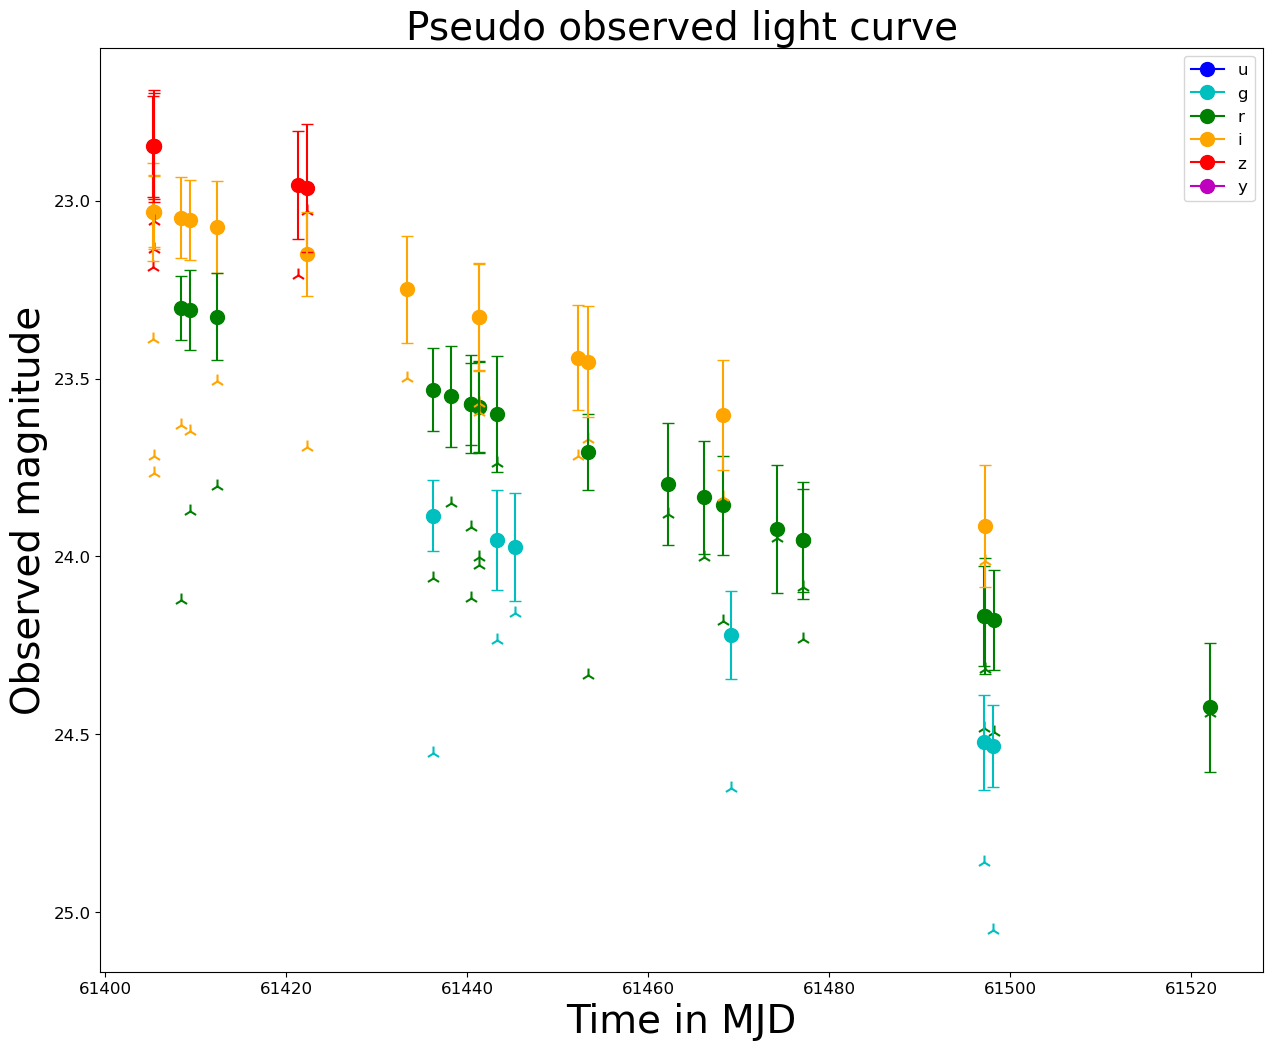

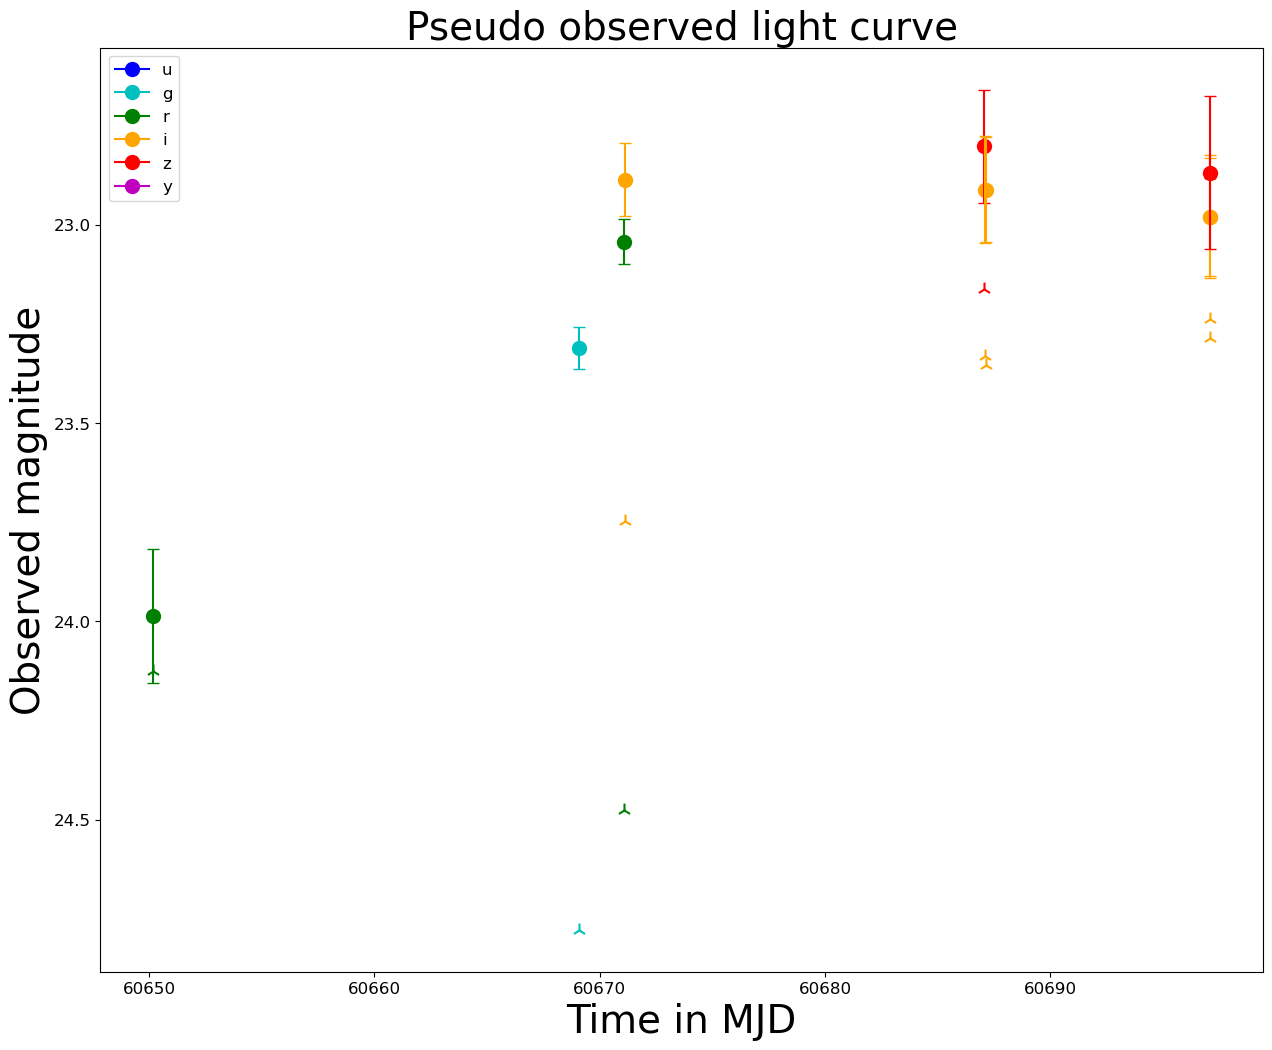

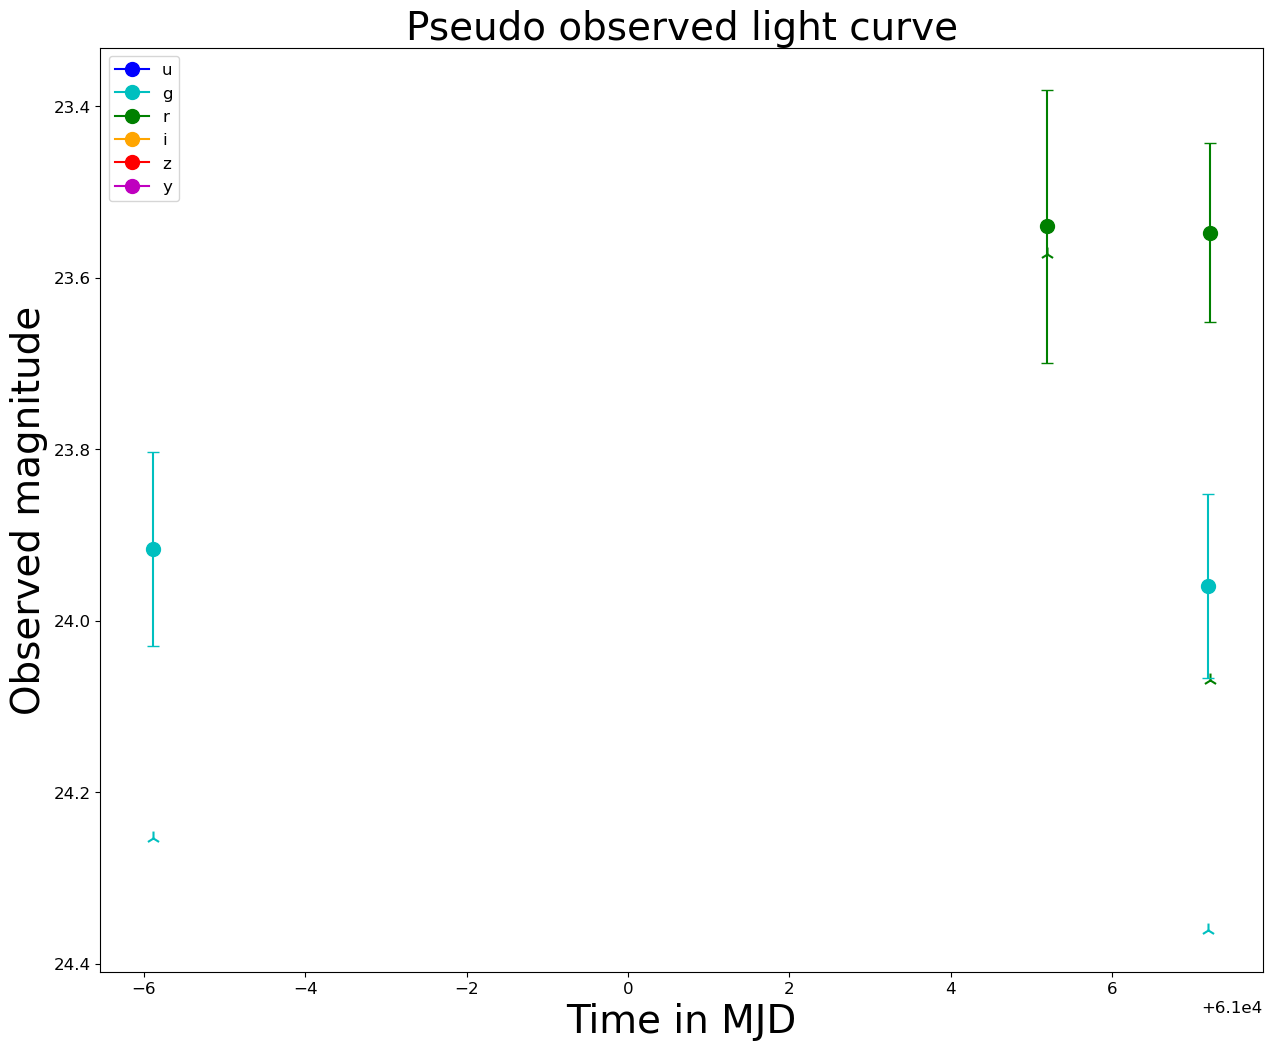

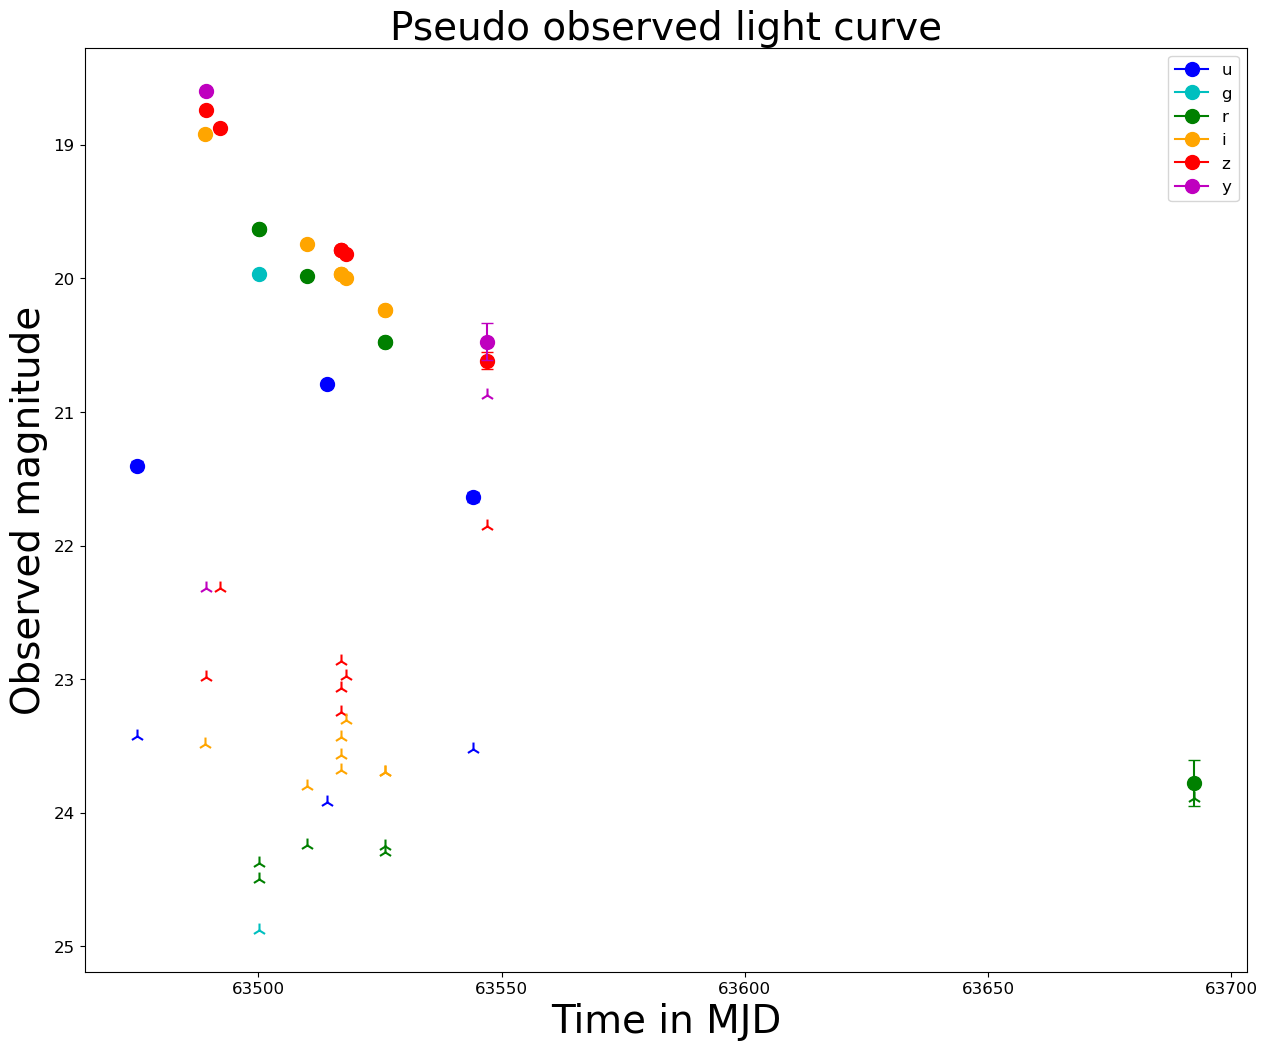

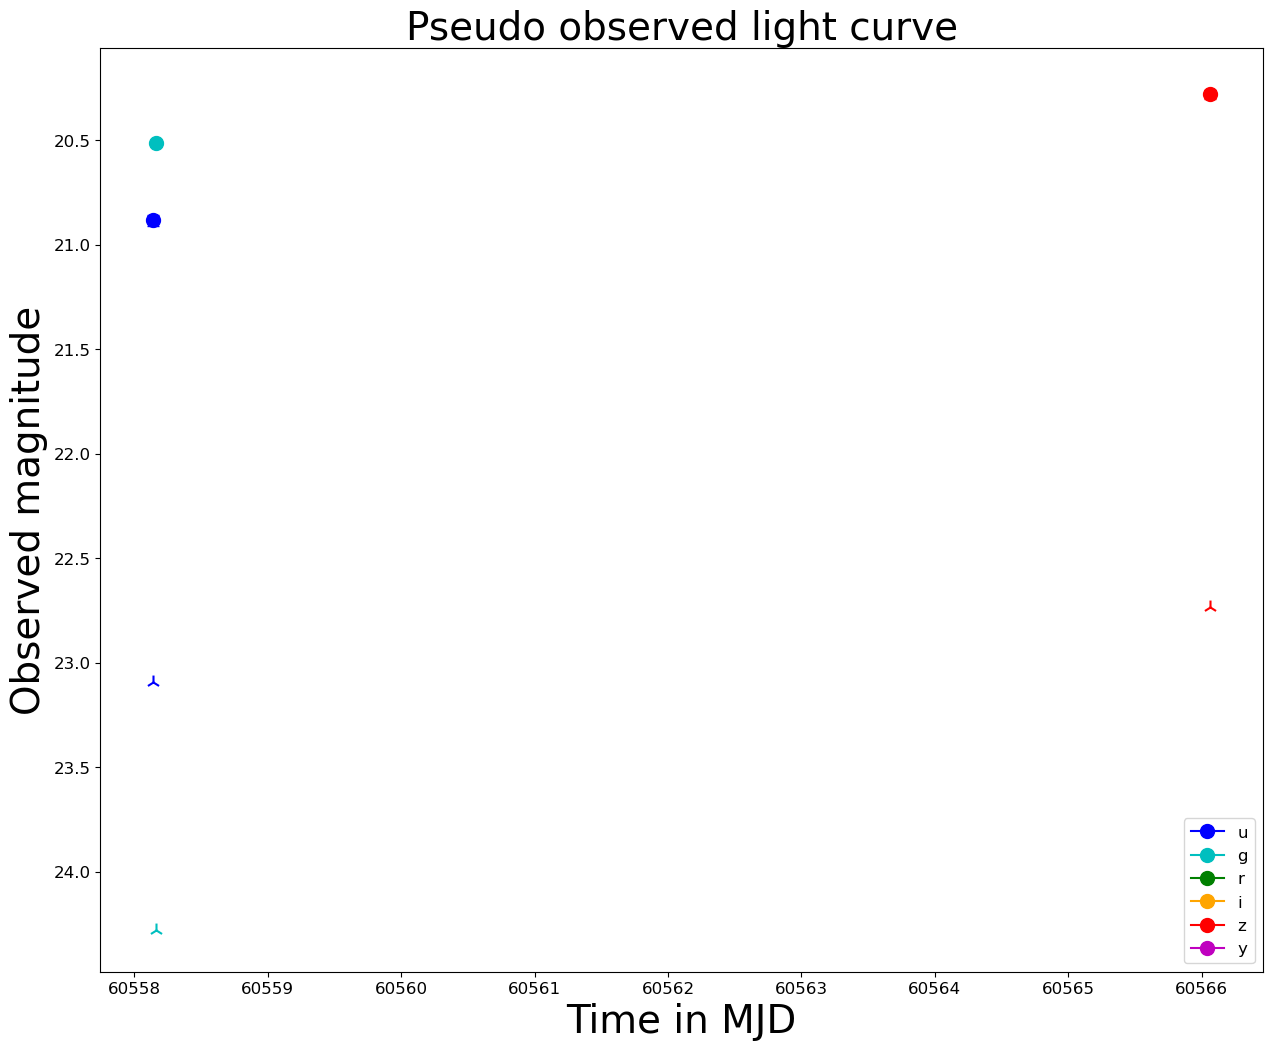

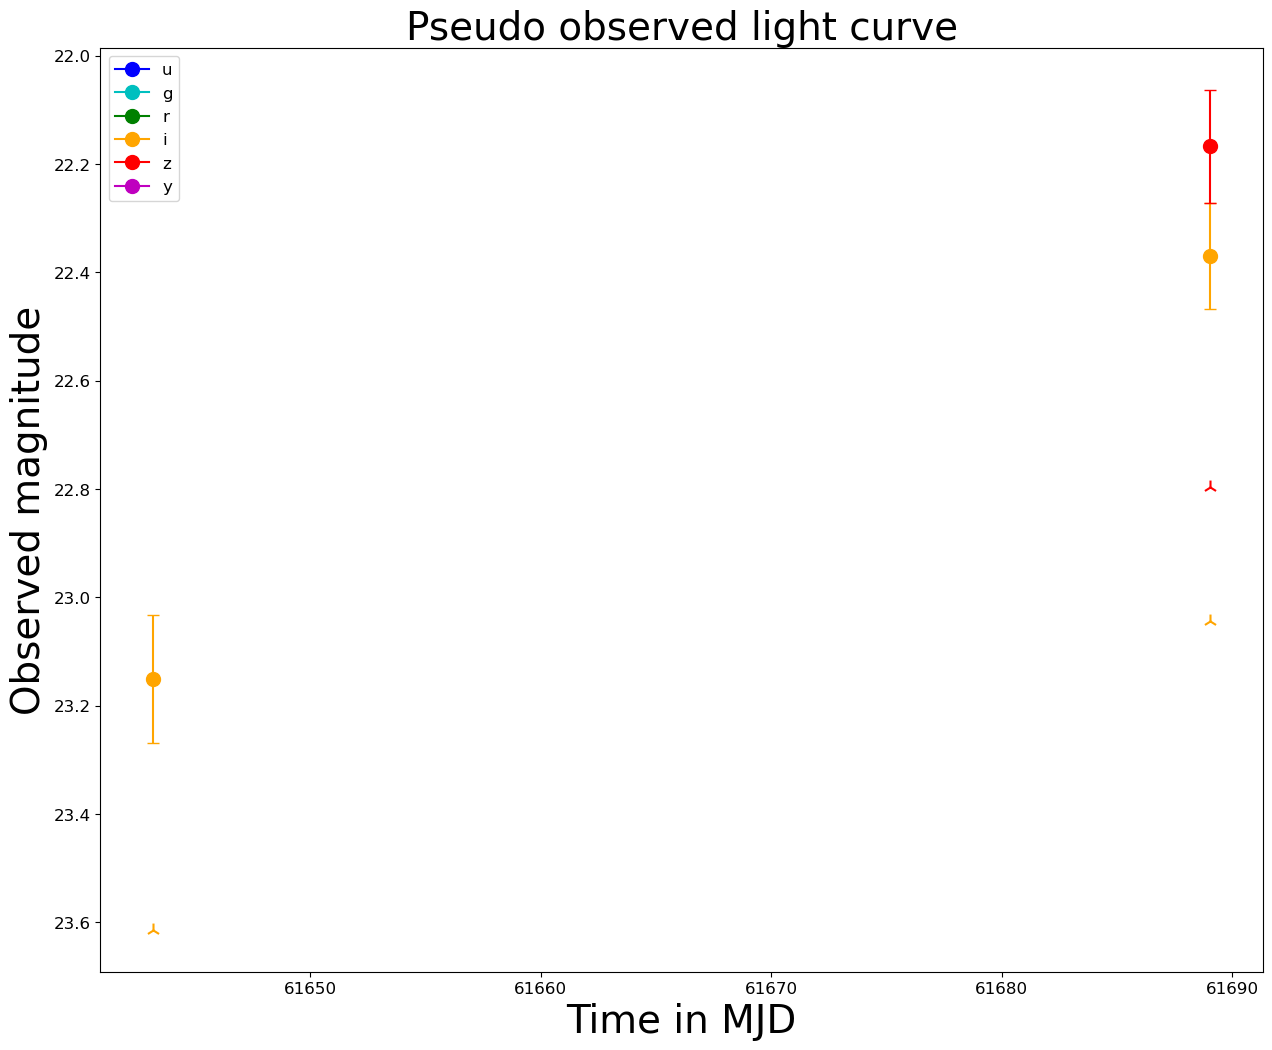

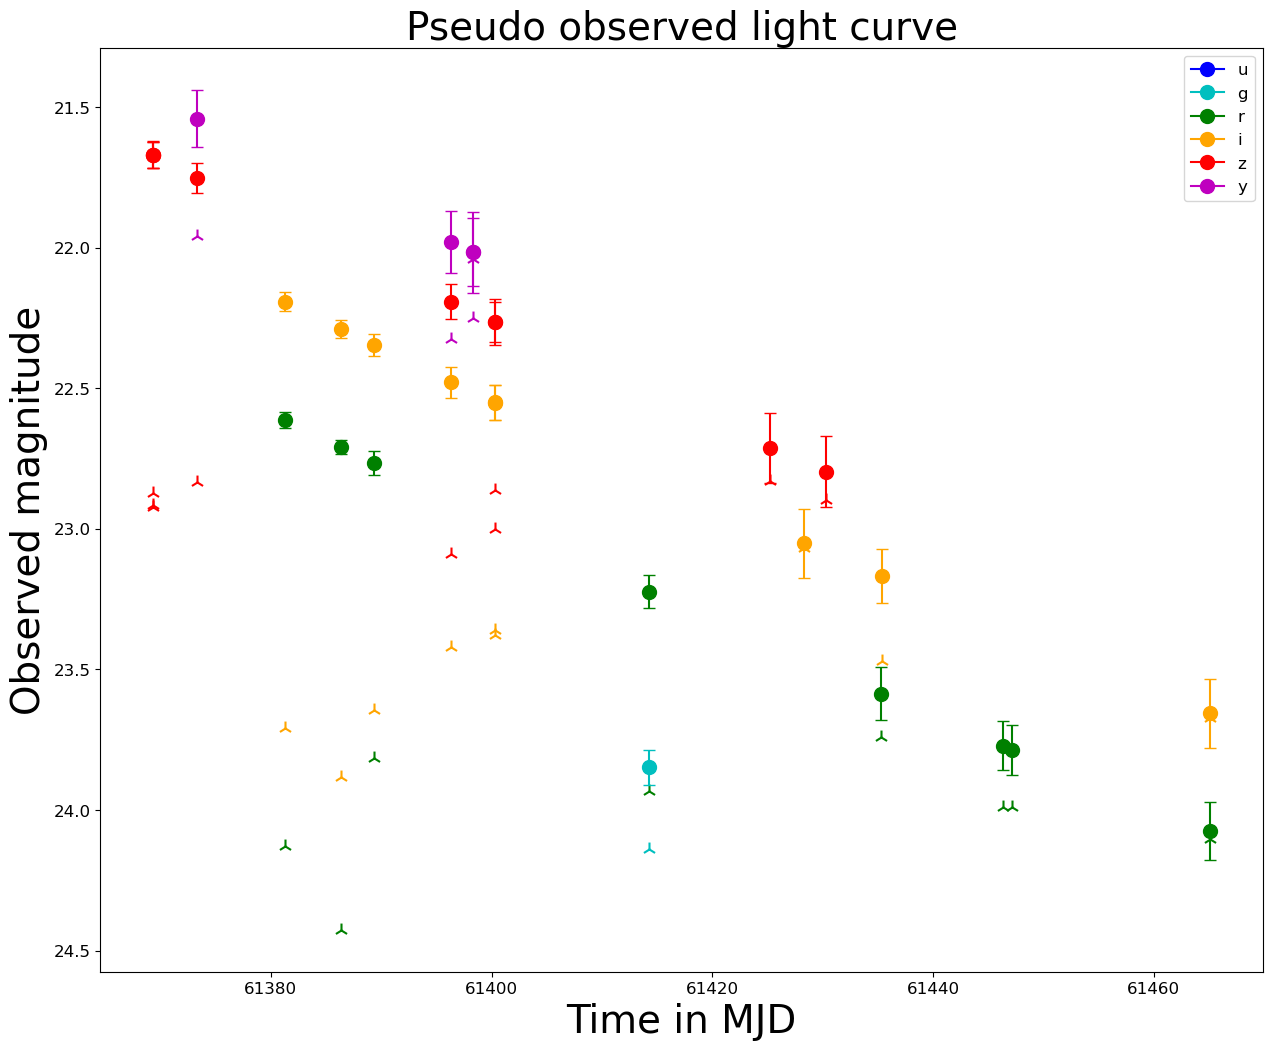

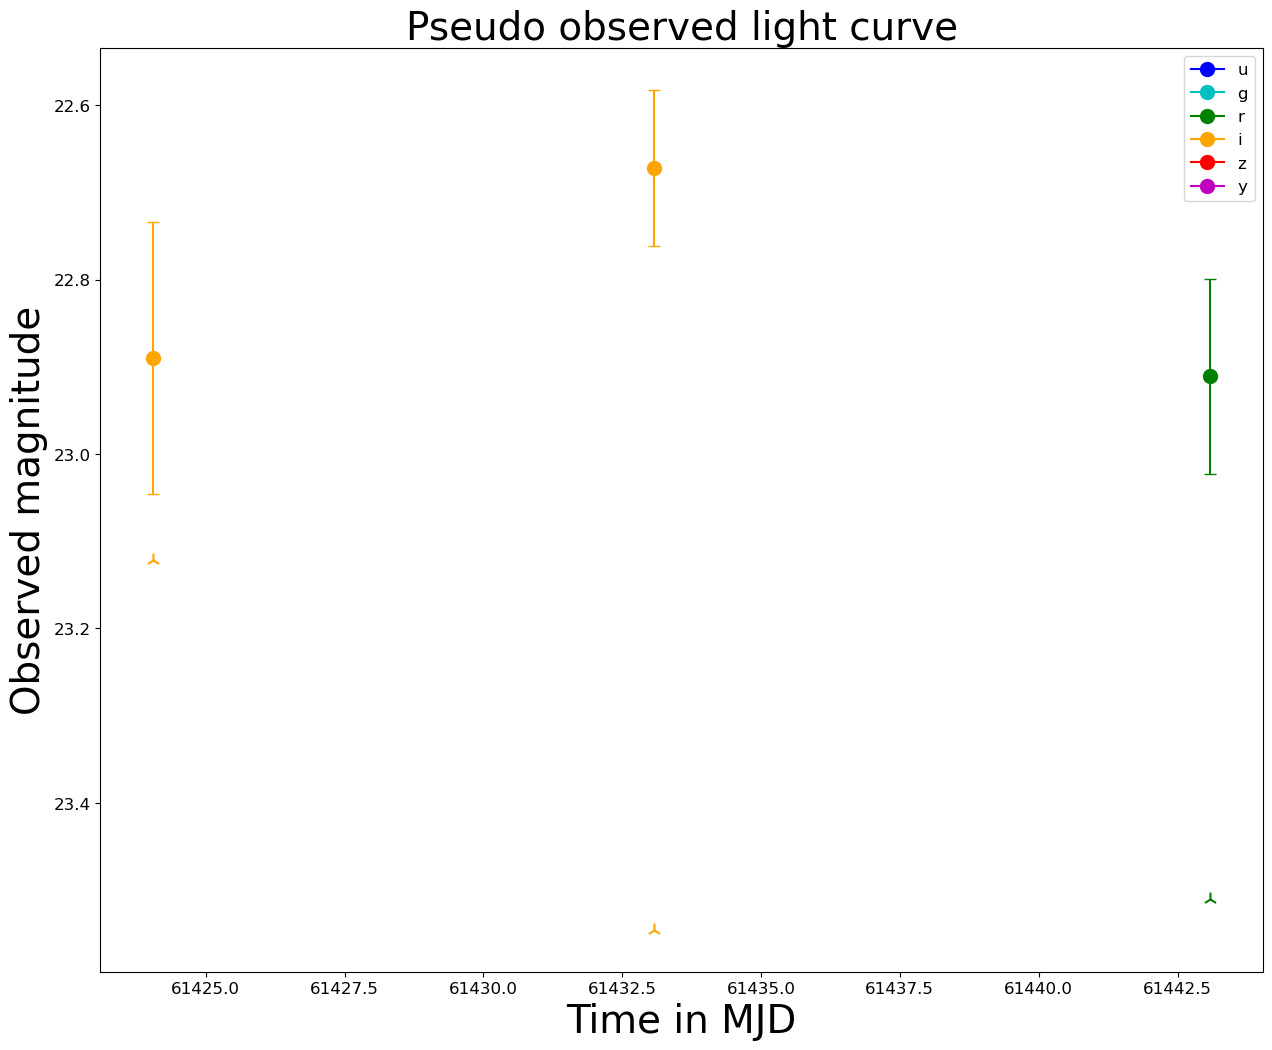

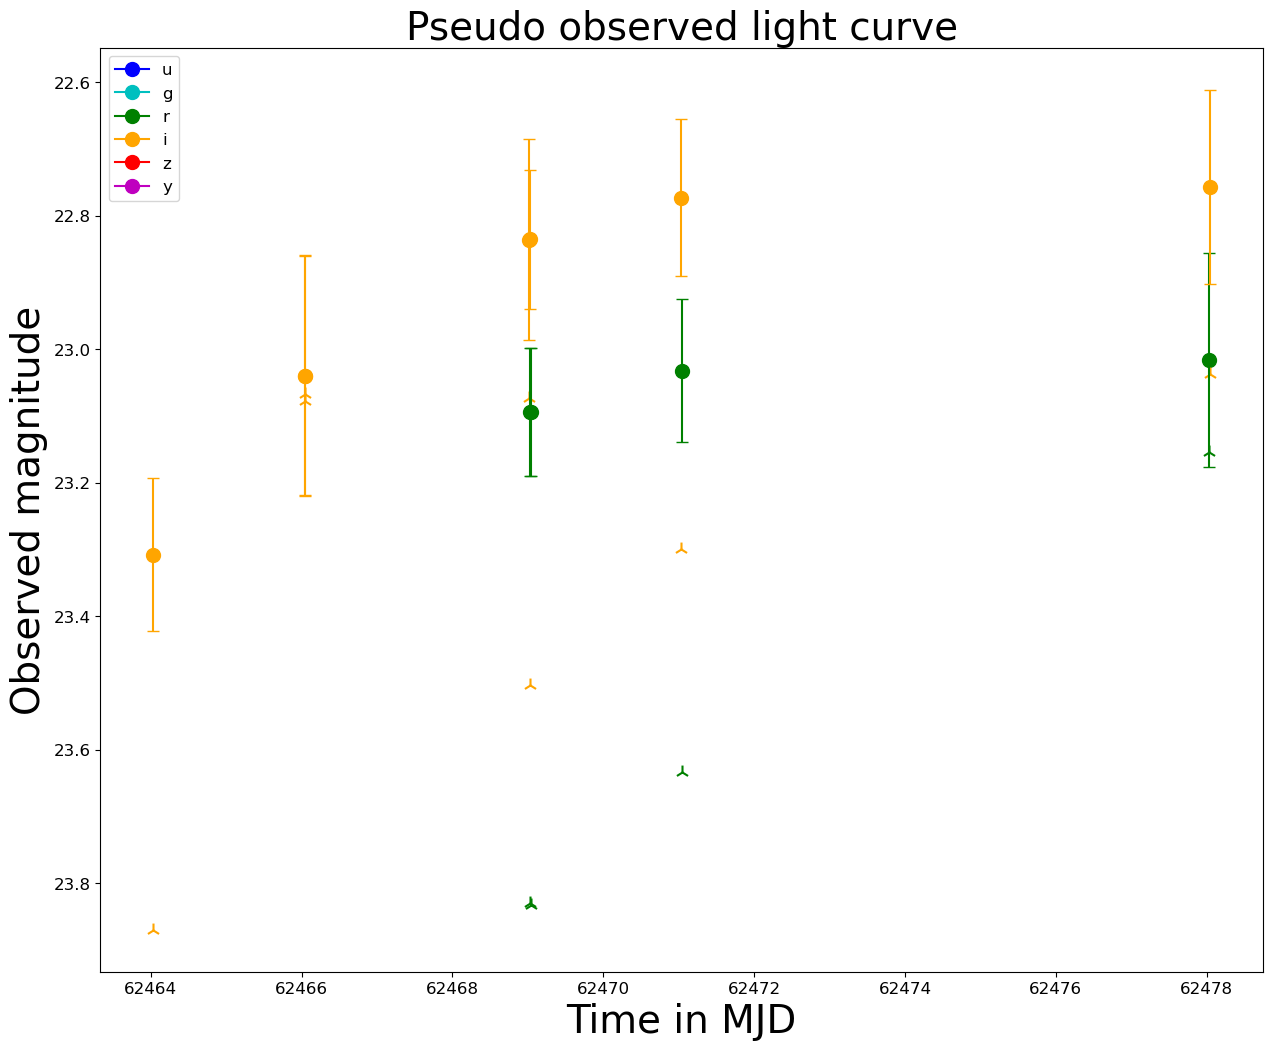

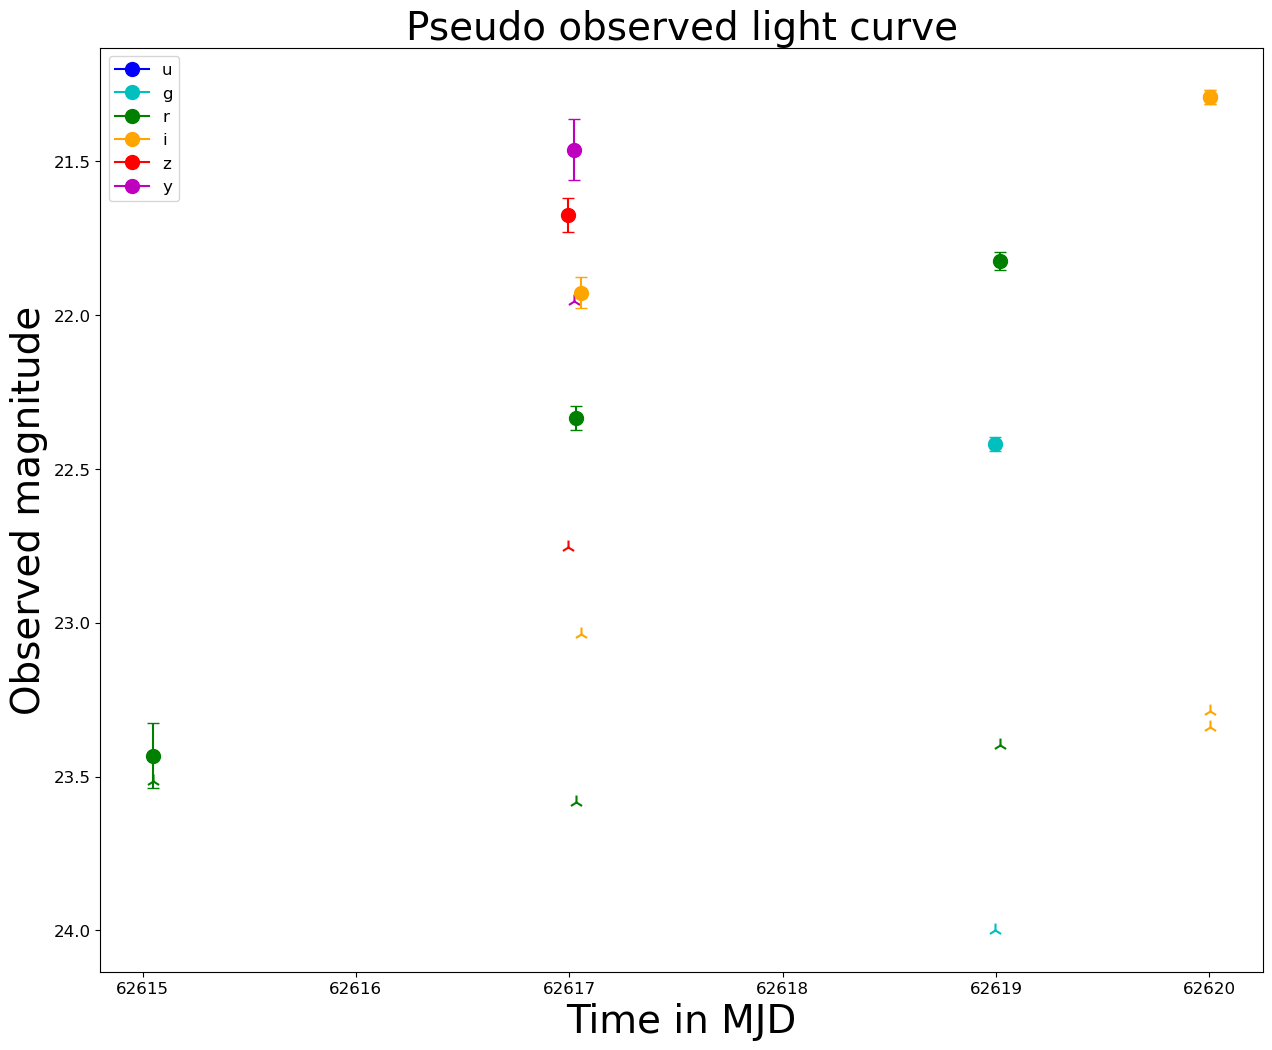

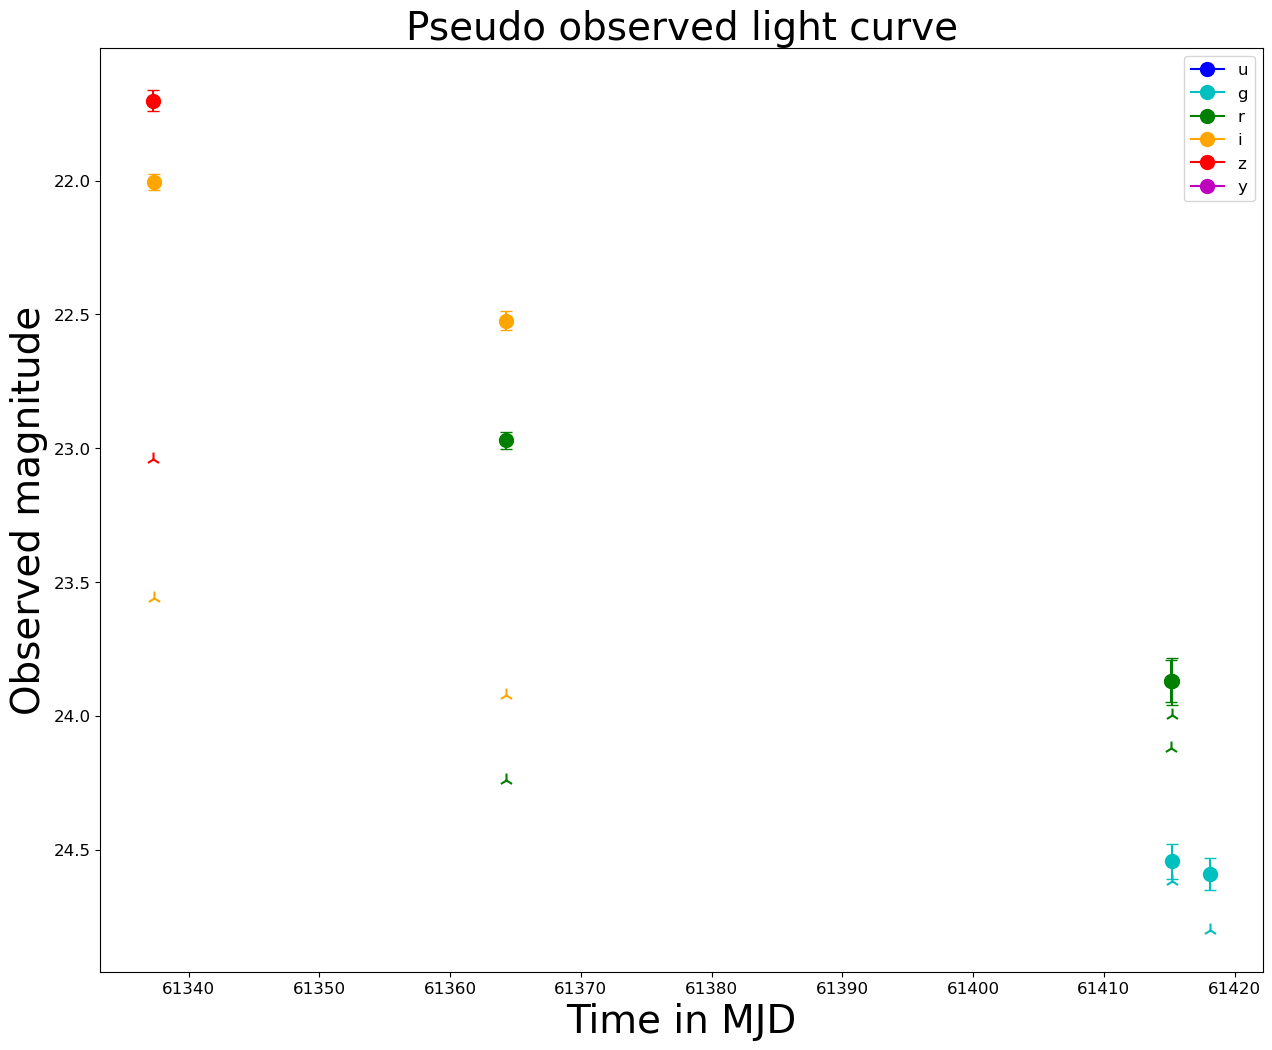

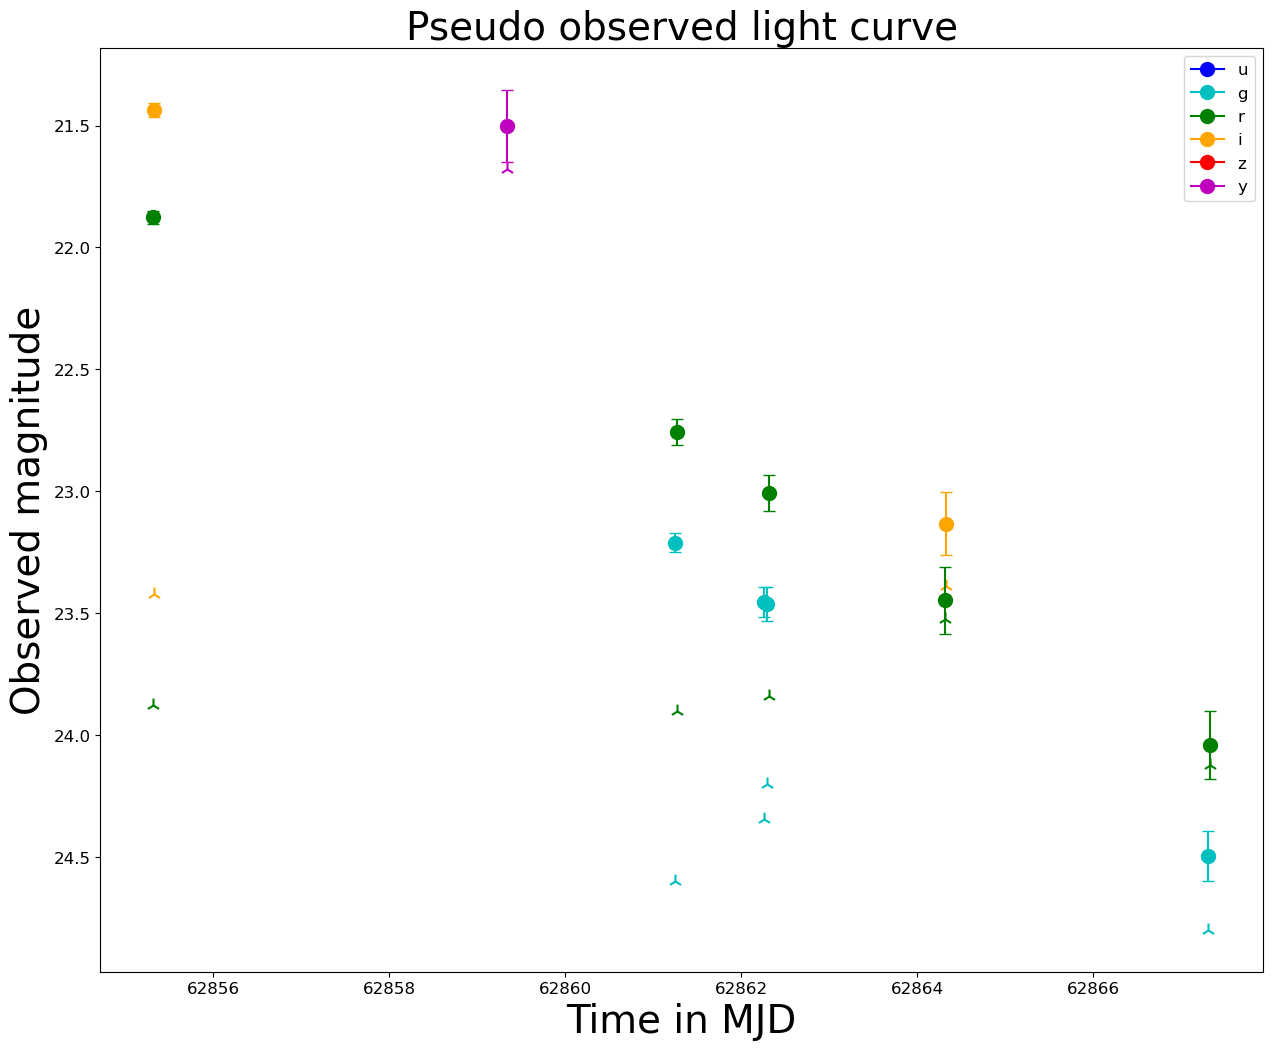

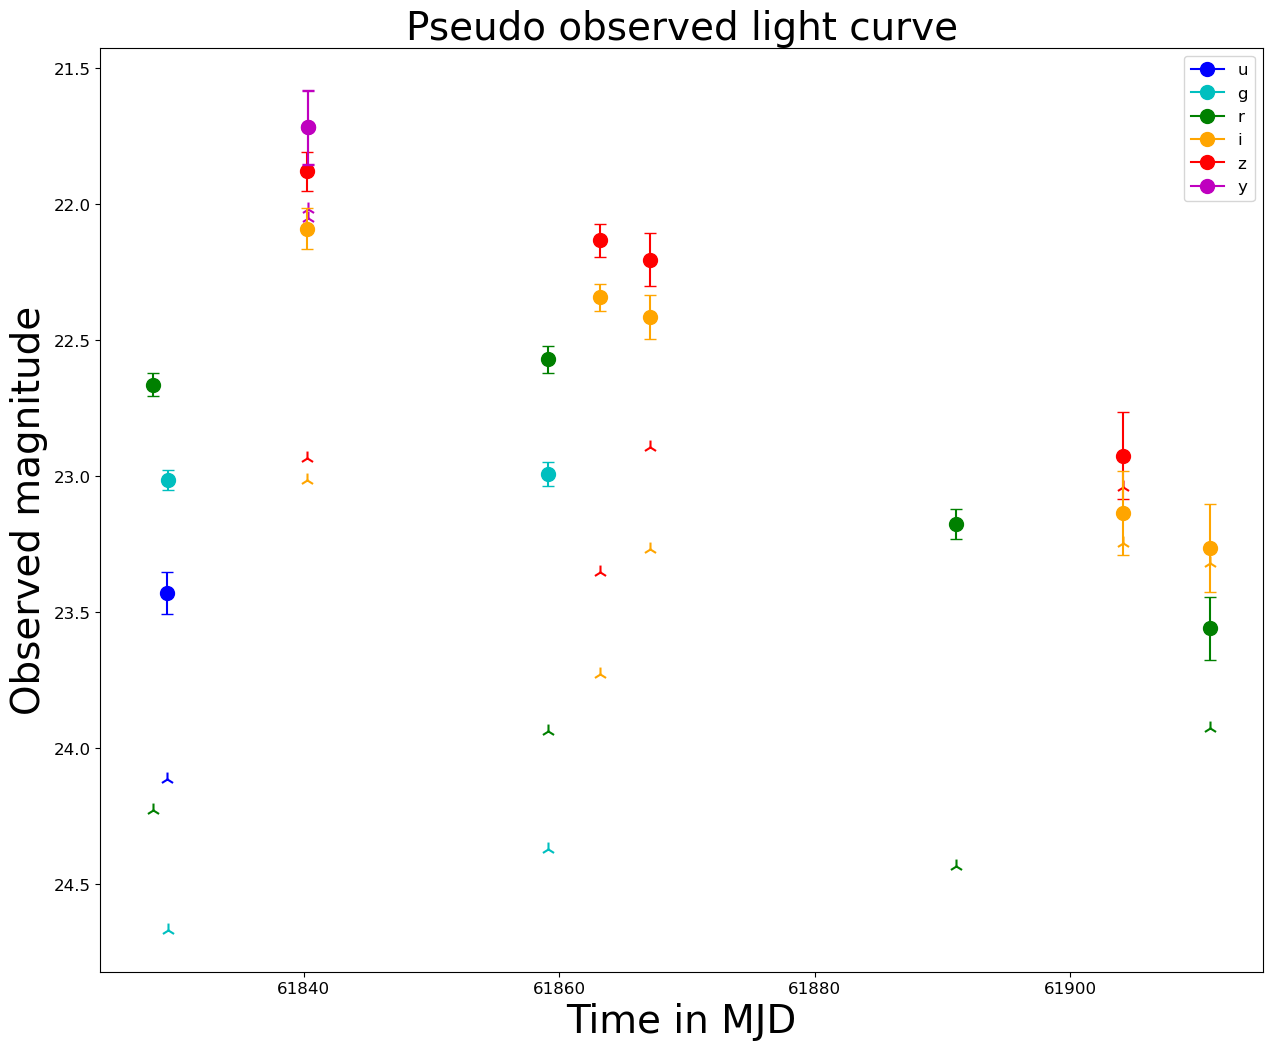

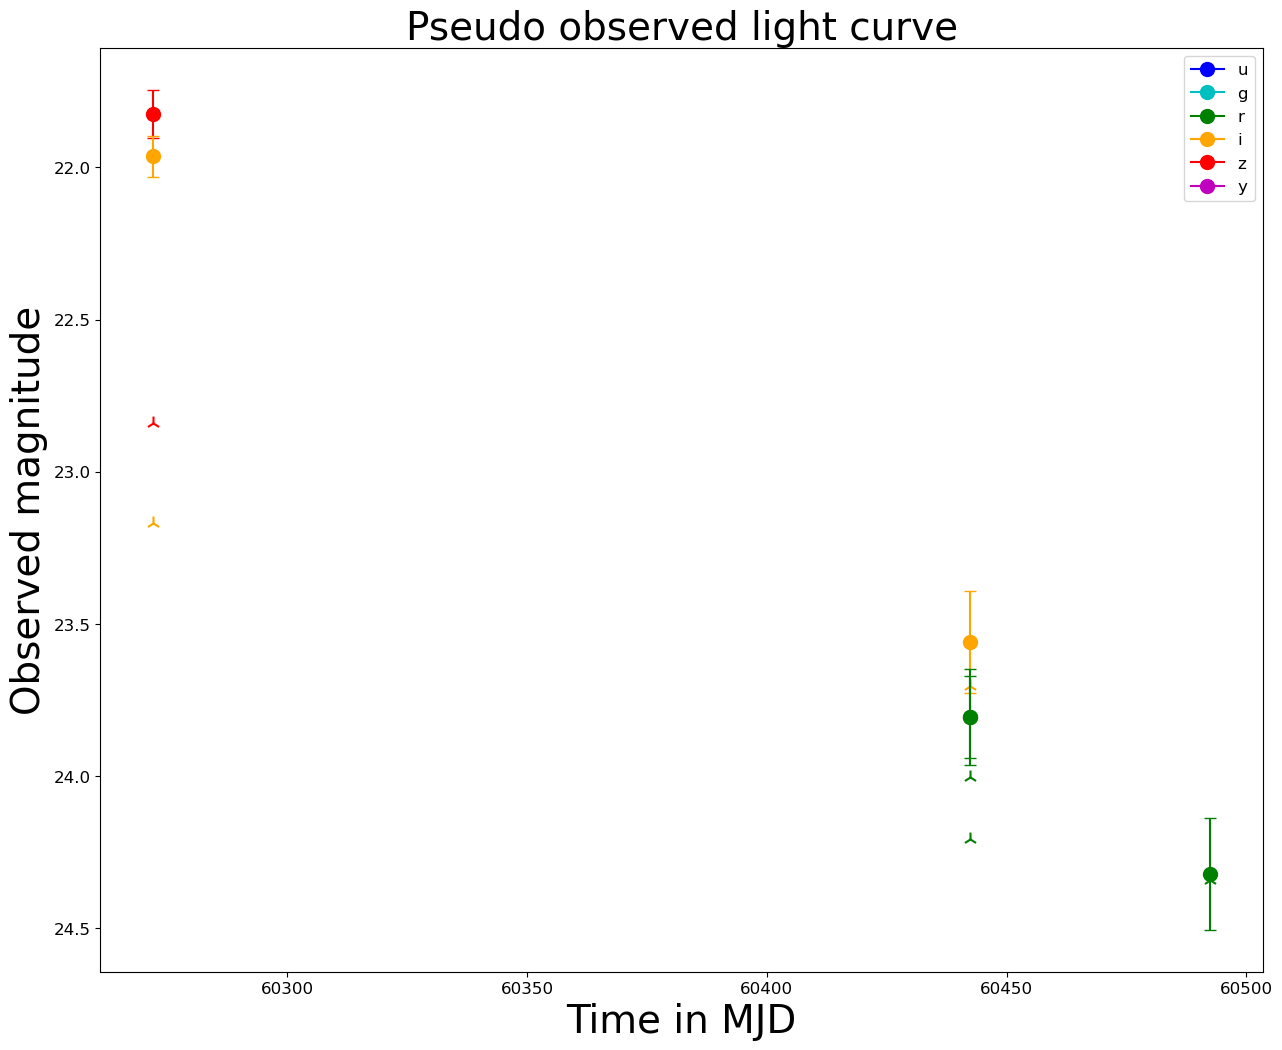

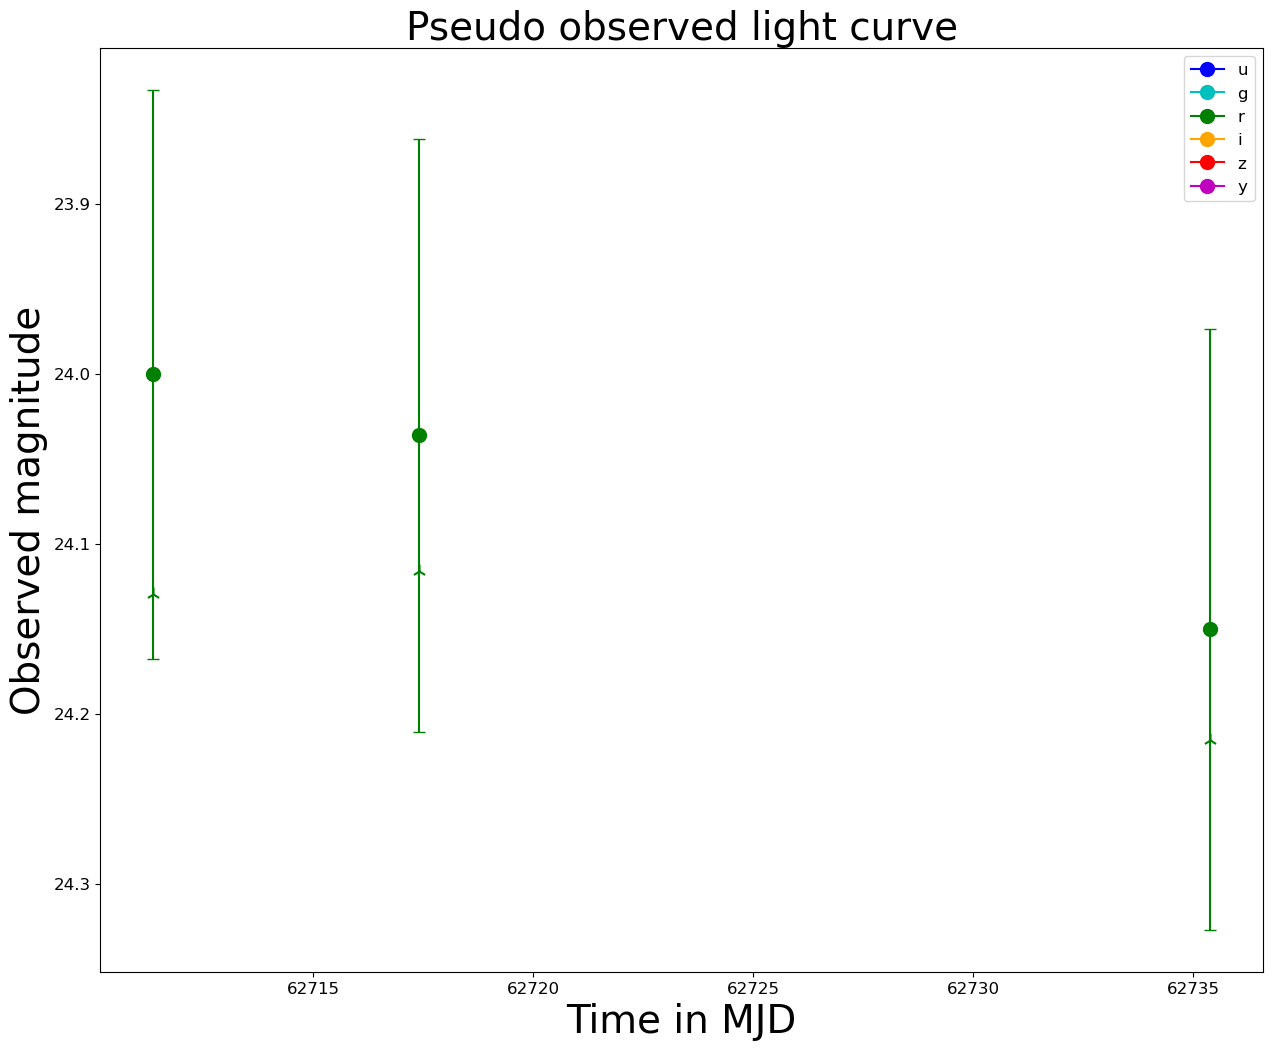

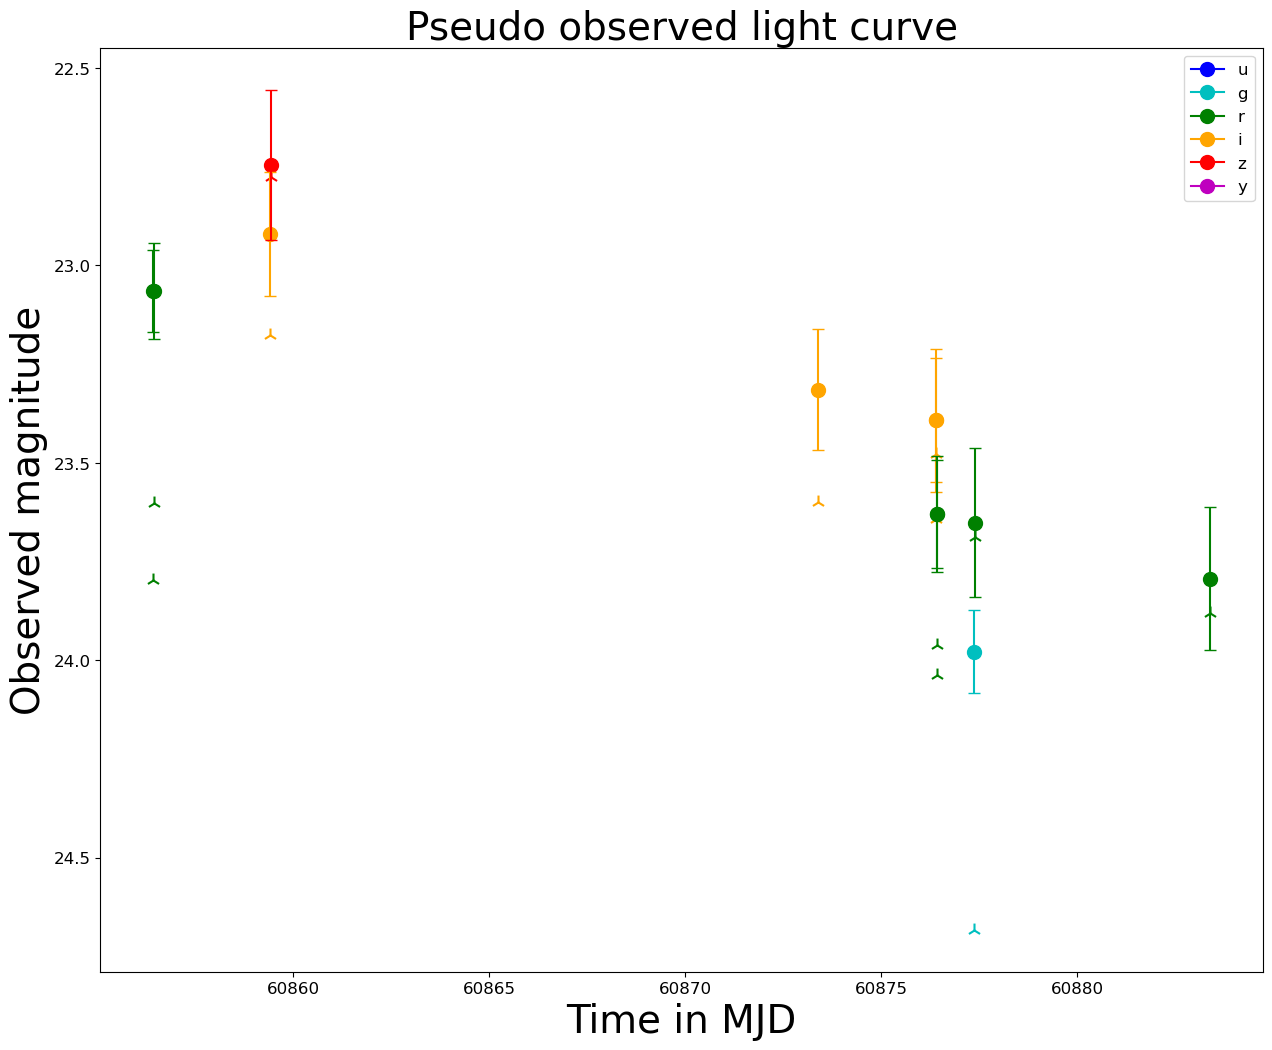

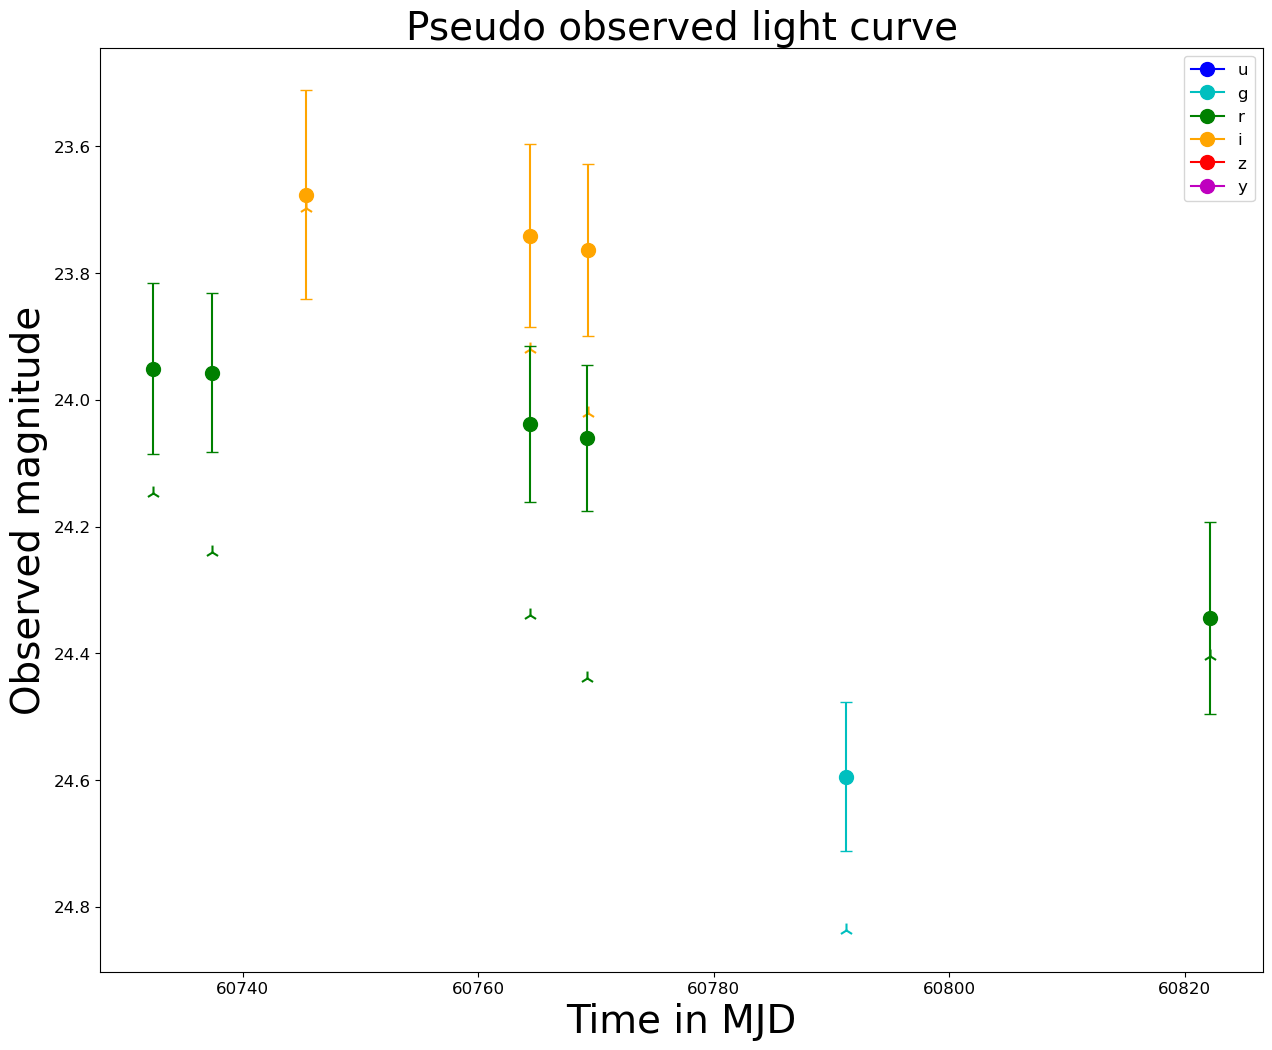

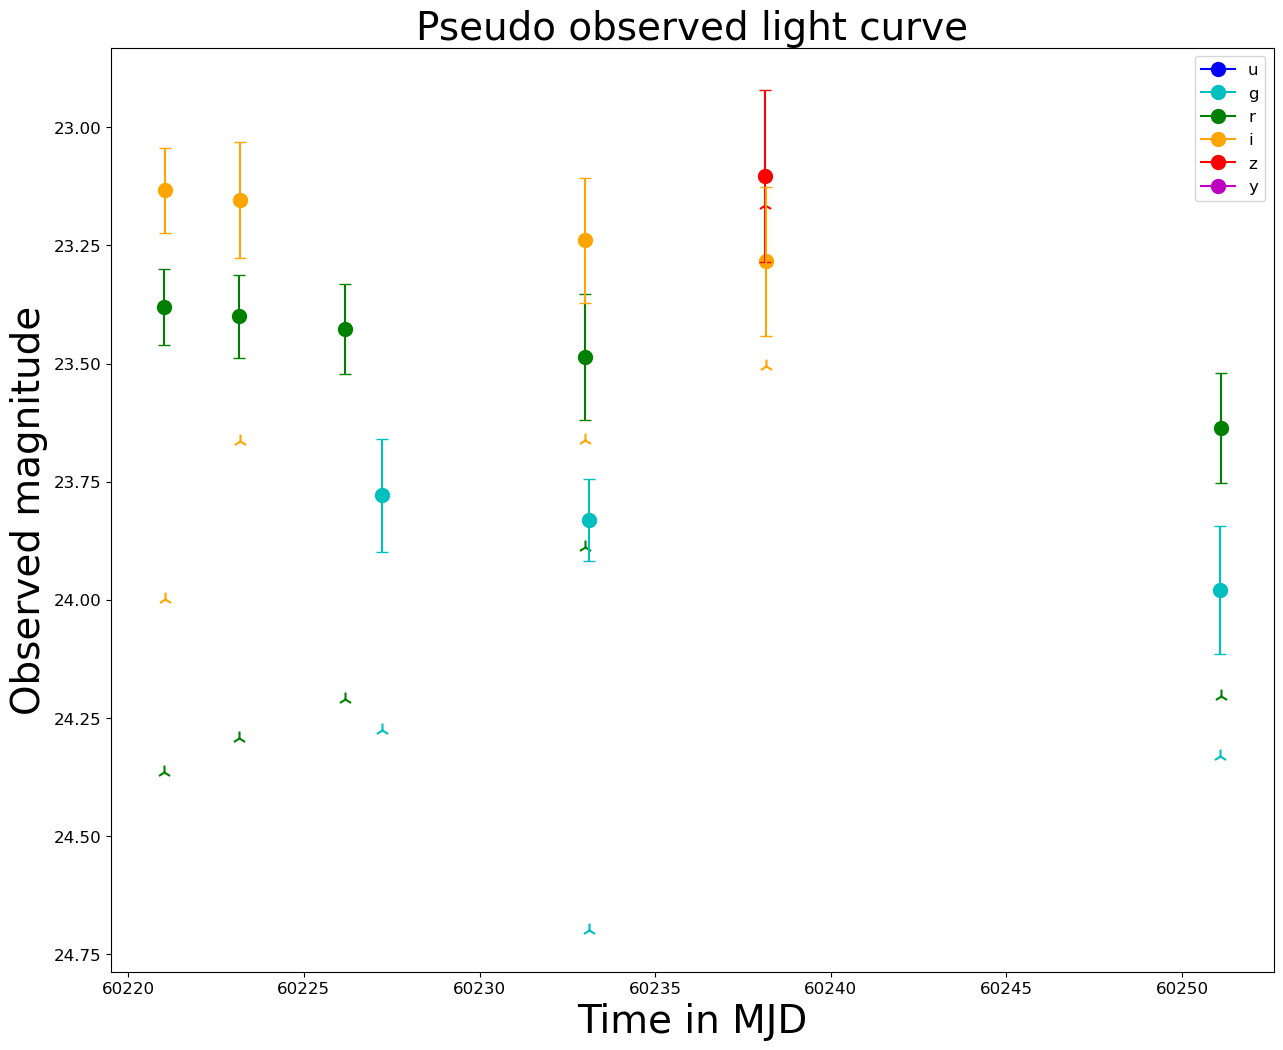

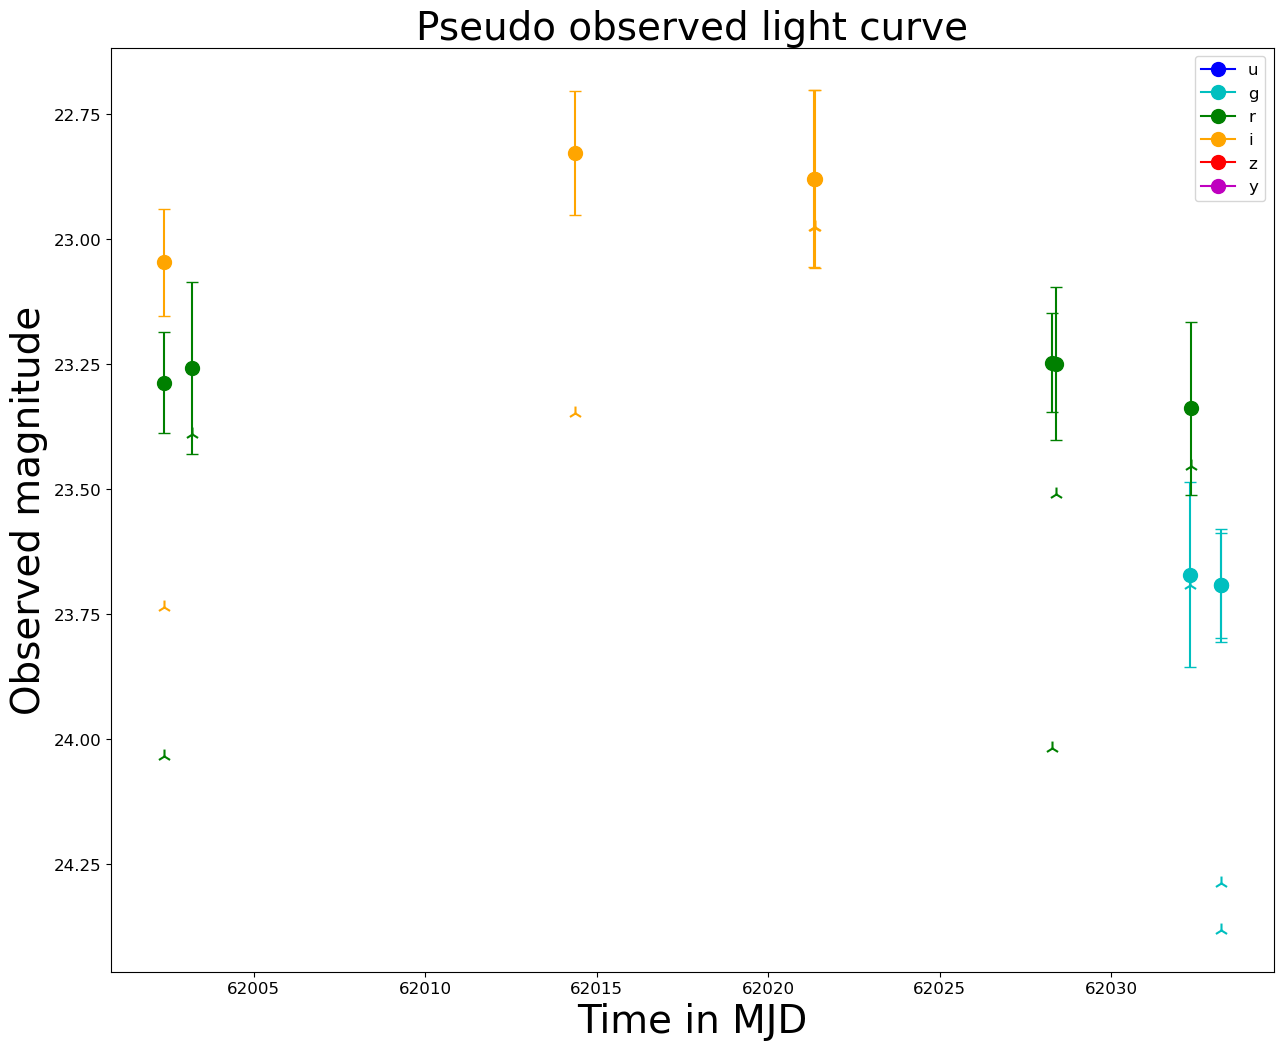

In [75]:
for i in range(len(lc_with_pts)):

    plot_pseudo_obs(lc_with_pts[i])

In [76]:
# compute galactic extinction to remove it in the data

coord = studied_lc['grb_coord']
a_lambda_u, a_lambda_g, a_lambda_r, a_lambda_i, a_lambda_z, a_lambda_y = galactic_extinction(coord, path_dustmaps)

# mean frequency in Hz of each band [u, g, r, i, z, y]

all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]
a_lambda = np.array([a_lambda_u, a_lambda_g, a_lambda_r, a_lambda_i, a_lambda_z, a_lambda_y])

In [77]:
# keeping only observable points and sorting them by filters

mags = studied_lc['mags']
filt = studied_lc['filt']
mags_lim = studied_lc['mags_lim']
mags_err = studied_lc['mags_err']
time = studied_lc['time']
grb_time = studied_lc['grb_time']

colors = ['b', 'c', 'g', 'orange', 'r', 'm']
all_mags = [[]]*6
all_mags_err = [[]]*6
all_times = [[]]*6


for c in colors:
    
    all_mags[colors.index(c)] = np.array([mags[i] for i in range(len(mags)) if filt[i] == c and
                                      mags[i] < mags_lim[i]])
    
    all_mags_err[colors.index(c)] = np.array([mags_err[i] for i in range(len(mags_err))
                                          if filt[i] == c and mags[i] < mags_lim[i]])
    
    all_times[colors.index(c)] = np.array([(time[i]-Time(grb_time).mjd)
                                       for i in range(len(time)) if filt[i] == c and mags[i] < mags_lim[i]])
                                       # time counted from from GRB T_0 ('grb_time')

# Fitting on the r-band

In [78]:
# data calculated in flux and corrected from galactic extinction

t = all_times[2]
y = pow(10, (26 - ((np.array(all_mags[2]) - a_lambda_r) + 48.6) / 2.5))
yerr = pow(10, (26 - ((np.array(all_mags[2]) - a_lambda_r) + all_mags_err[2] + 48.6) / 2.5)) - y

In [79]:
def model(t, nu, params):
    
    Z = {'jetType': -1,
         'specType': 0,
         'b': 4,
         'thetaCore': 0.15,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0,
         'z': 0.08298790581165529}

    E, thetaObs, thetaWing, n = params

    return grb.fluxDensity(t*grb.day2sec, nu, E0=10**E, thetaObs=thetaObs, thetaWing=thetaWing, n0=10**n,
                           d_L=cosmo.luminosity_distance(Z['z']).value * 3.08e24, **Z)


def lnlike(p, t, y, yerr):
    """ Compute ln of likelihood
    """
    
    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """
    
    E, thetaObs, thetaWing, n = p

    # uniform priors
    if (51. < E < 55. and 0.16 < thetaWing < 0.3 and thetaWing < thetaObs < np.pi/4 
        and np.log10(0.01) < n < np.log10(10.)):
        return 0.0

    return -np.inf


def lnpost(p, t, y, yerr):
    """ Compute ln of parameters posteriors
    """
    
    lp = lnprior(p)

    return lp + lnlike(p, t, y, yerr) if np.isfinite(lp) else -np.inf


def sample_walkers(nsamples, flattened_chain, nu):
    """ Compute the median model and the spread in posteriors of the MCMC
    """
    
    models = []
    draw = np.floor(np.random.uniform(0, len(flattened_chain), size=nsamples)).astype(int)
    thetas = flattened_chain[draw]
    
    for i in thetas:
        
        mod = model(t_fit, nu, i)
        models.append(mod)
        
    spread = np.std(models, axis=0)
    med_model = np.median(models, axis=0)
    
    return med_model, spread

In [80]:
# data gathered in a tuple
data = (t, y, yerr)

# r-band mean frequency in Hz
nu = np.array(np.array(all_times[2]).shape)
nu[:] = all_nu[2]

nwalkers = 30

initial = np.array([54., 0.3, 0.2, 0.])
ndim = len(initial)

# initial position vector
p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim)
      for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)

print("Running burn-in...")
p0, _, _ = sampler.run_mcmc(p0, 1000, progress=True);
sampler.reset()

print("Running production...")
sampler.run_mcmc(p0, 15000, progress=True);

print("Done!")

Running burn-in...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 30.06it/s]


Running production...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [07:03<00:00, 35.44it/s]

Done!


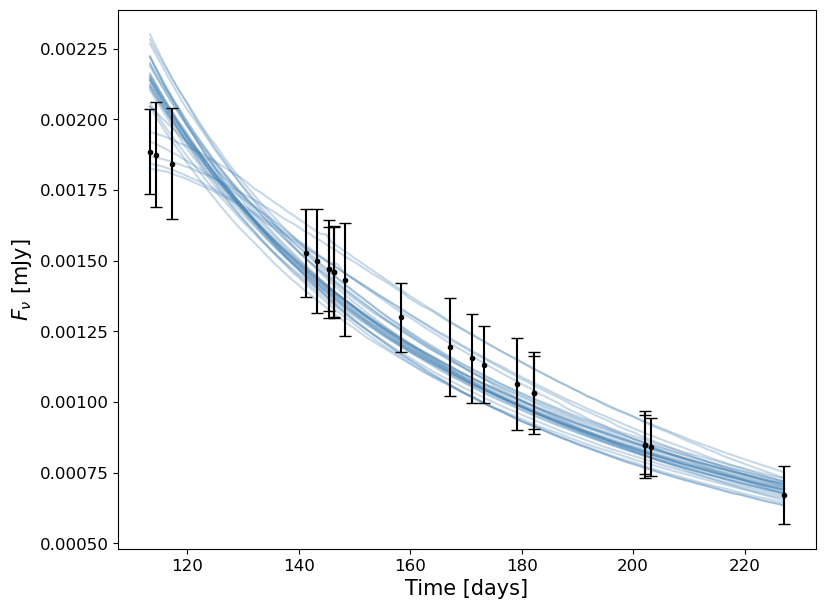

In [81]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# time used to compute fitted model
t_fit = np.geomspace(min(t), max(t), num=100)

# plot 30 posterior samples
samples = sampler.flatchain

for s in samples[np.random.randint(len(samples), size=30)]:
    plt.plot(t_fit, model(t_fit, nu, s), color="#4682b4", alpha=0.3)

# plot the data
plt.errorbar(t, y, yerr=yerr, fmt=".k", capsize=4)
 
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.show()

In [83]:
best_params

array([5.31708357e+01, 6.39215827e-01, 2.26336527e-01, 1.39380557e-02])

The best parameters are: E0 = 1.481957350179633e+53 erg, thetaObs = 0.6392158274703088 rad, thetaWing = 0.22633652684661829 rad, n0 = 1.0326141113782379
The true parameters are: E0 = 4.9456323589364086e+54 erg, thetaObs = 0.4842197630655113 rad, thetaWing = 0.24073747003192078 rad, n0 = 3.8694121517374027, z = 0.08298790581165529


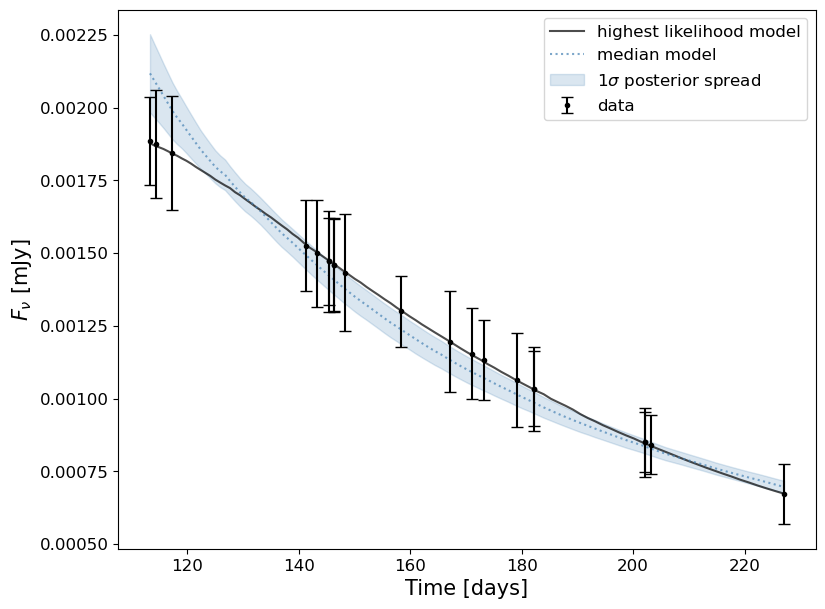

In [84]:
# plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# median model and spread in posteriors for 100 samples
med_model, spread = sample_walkers(30, samples, nu)

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

print(f"The best parameters are: E0 = {10**best_params[0]} erg, thetaObs = {best_params[1]} rad, thetaWing = {best_params[2]} rad, n0 = {10**best_params[3]}")
print(f"The true parameters are: E0 = {studied_lc['config']['E0']} erg, thetaObs = {studied_lc['config']['thetaObs']} rad, thetaWing = {studied_lc['config']['thetaWing']} rad, n0 = {studied_lc['config']['n0']}, z = {studied_lc['config']['z']}")

plt.plot(t_fit, best_fit_model, color="k", alpha=0.7, label='highest likelihood model')
plt.plot(t_fit, med_model, color="#4682b4", alpha=0.7, label='median model', ls=':')
plt.fill_between(t_fit, med_model - spread, med_model + spread, color="#4682b4", alpha=0.2,
                 label=r'$1\sigma$ posterior spread')

plt.errorbar(t, y, yerr=yerr, fmt=".k", capsize=4, label='data')


plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.legend()

plt.show()

In [85]:
names = [r'$logs_{10}(E_0)$', r'$\theta_{obs}$', r'$\theta_w$', r'$log_{10}(n_0)$']
settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_one_band = MCSamples(samples=samples, names=names, settings=settings)

Removed no burn in


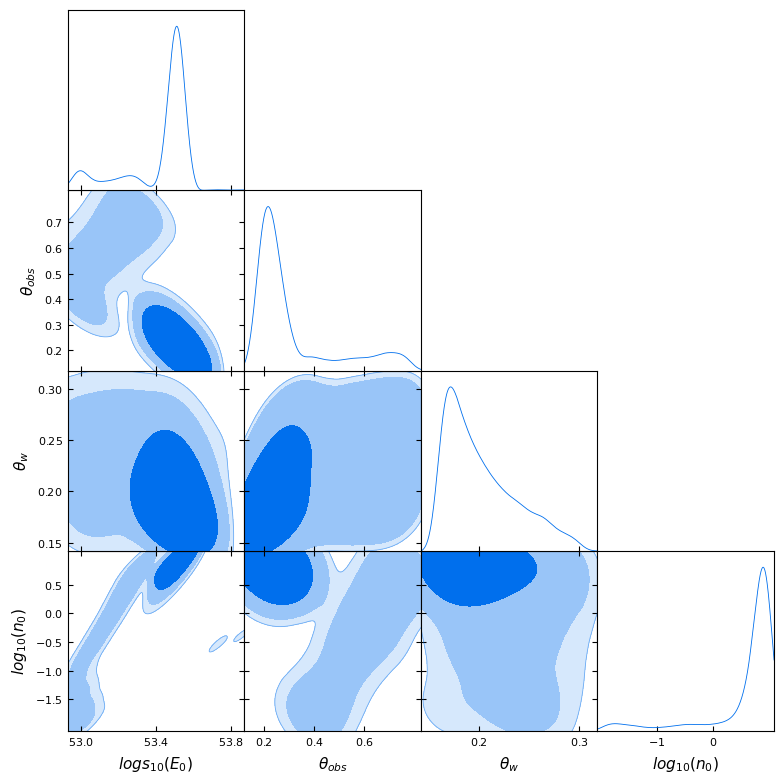

In [86]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.triangle_plot(samples_one_band, filled=True)

# Fitting on all bands

In [87]:
# data calculated in flux and corrected from galactic extinction

t = all_times
y = pow(10, (26 - ((np.array(all_mags) - a_lambda) + 48.6) / 2.5))
yerr = pow(10, (26 - ((np.array(all_mags) - a_lambda) - np.array(all_mags_err) + 48.6) / 2.5)) - y

/tmp/ipykernel_534644/653256957.py:4: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = pow(10, (26 - ((np.array(all_mags) - a_lambda) + 48.6) / 2.5))
/tmp/ipykernel_534644/653256957.py:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  yerr = pow(10, (26 - ((np.array(all_mags) - a_lambda) - np.array(all_mags_err) + 48.6) / 2.5)) - y


In [90]:
def model(t, nu, params):
    
    Z = {'jetType': -1,
         'specType': 0,
         'b': 4,
         'thetaCore': 0.15,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0,
         'z': 0.08298790581165529}

    E, thetaObs, thetaWing, n = params

    if thetaObs < thetaWing or np.pi/2 < thetaObs:
        thetaObs = 0.01
        
    return grb.fluxDensity(t*grb.day2sec, nu, E0=10**E, thetaObs=thetaObs, thetaWing=thetaWing, n0=10**n,
                           d_L=cosmo.luminosity_distance(Z['z']).value * 3.08e24, **Z)


def lnlike(p, t, y, yerr, nu):
    """ Compute ln of likelihood
    """
    
    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """
    
    E, thetaObs, thetaWing, n = p

    # uniform priors
    if (51. < E < 55. and 0.16 < thetaWing < 0.3 and thetaWing < thetaObs < np.pi/4 
        and np.log10(0.01) < n < np.log10(10.)):
        return(0.0)

    return(-np.inf)


def lnpost(p, t, y, yerr, nu):
    """ Compute ln of parameters posteriors
    """
    
    lp = lnprior(p)
    all_lnlike = []
    
    # compute ln likelihood for each data set with at least 2 points
    for i in range(6):
        if len(y[i]) > 1:
            all_lnlike.append(lnlike(p, t[i], y[i], yerr[i], nu[i]))

    # sum of all ln likelihoods tp use all datasets in the fit
    return lp + sum(all_lnlike) if np.isfinite(lp) else -np.inf


def sample_walkers(nsamples, flattened_chain, nu):
    """ Compute the median model and the spread in posteriors of the MCMC
    """
    
    models = []
    draw = np.floor(np.random.uniform(0, len(flattened_chain),size=nsamples)).astype(int)
    thetas = flattened_chain[draw]
    
    for i in thetas:
        
        mod = model(t_fit, nu, i)
        models.append(mod)
        
    spread = np.std(models,axis=0)
    med_model = np.median(models,axis=0)
    
    return med_model,spread

In [91]:
# data gathered in a tuple
data = (t, y, yerr, all_nu)

nwalkers = 30

initial = np.array([54., 0.3, 0.2, 0.])
ndim = len(initial)

# initial position vector
p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim)
      for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)

print("Running burn-in...")
p0, _, _ = sampler.run_mcmc(p0, 500, progress=True)
sampler.reset()

print("Running production...")
sampler.run_mcmc(p0, 10000, progress=True)

print("Done!")

Running burn-in...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:14<00:00,  6.72it/s]


Running production...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [22:55<00:00,  7.27it/s]

Done!


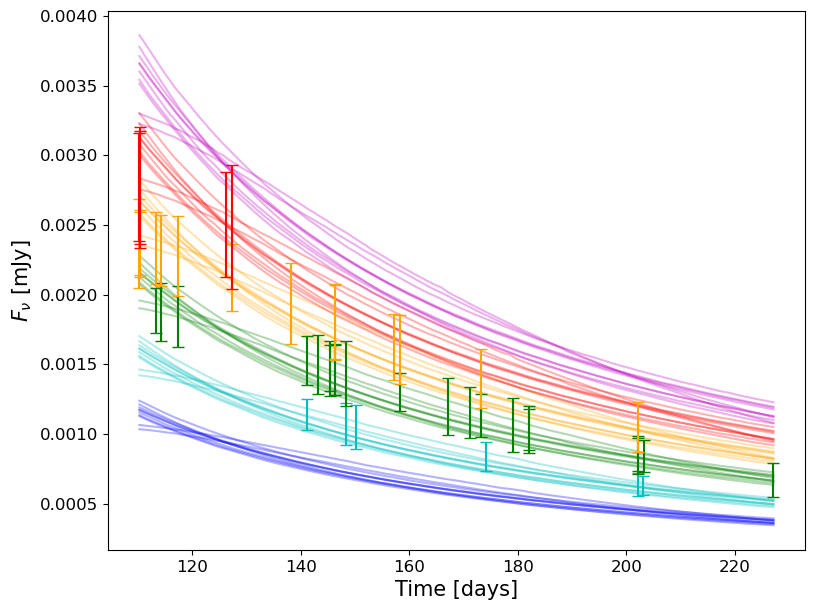

In [92]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# times of the first and last detections
t_min = min(np.min(all_times[i]) for i in range(6) if len(all_times[i]) > 0)
t_max = max(np.max(all_times[i]) for i in range(6) if len(all_times[i]) > 0)

# time used to compute fitted model
t_fit = np.geomspace(t_min, t_max, num=100)

# Plot the 10 same posterior samples for each band
samples = sampler.flatchain
for s in samples[np.random.randint(len(samples), size=10)]:
    for i in range(6):
        plt.plot(t_fit, model(t_fit, all_nu[i], s), color=colors[i], alpha=0.3)

# plot the data
for i in range(6):
    plt.errorbar(t[i], y[i], yerr=yerr[i], capsize=4, color=colors[i], ls='')
    
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.show()

The best parameters are: E0 = 1.0670752760712879e+53 erg, thetaObs = 0.5366656737293387 rad, thetaWing = 0.25757398240937546 rad, n0 = 0.1857652187839754
The true parameters are: E0 = 4.9456323589364086e+54 erg, thetaObs = 0.4842197630655113 rad, thetaWing = 0.24073747003192078 rad, n0 = 3.8694121517374027, z = 0.08298790581165529


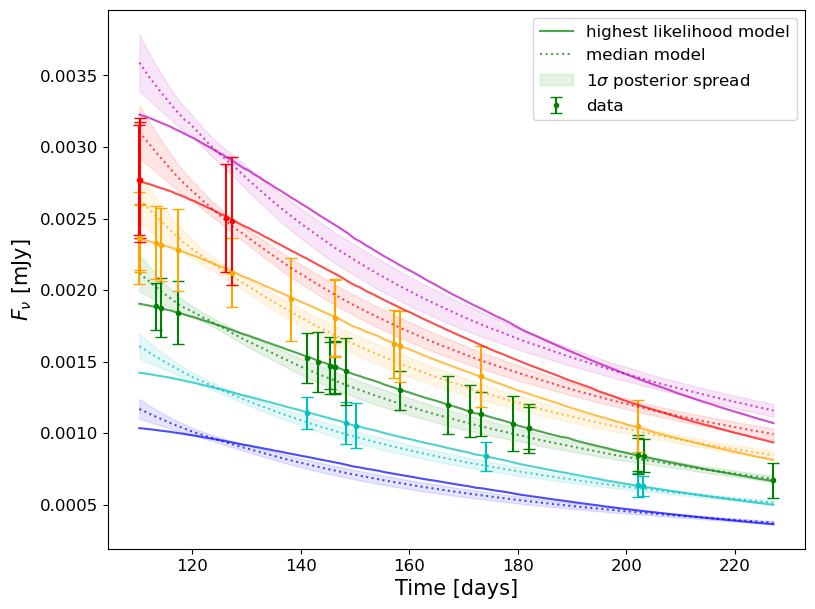

In [93]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]

print(f"The best parameters are: E0 = {10**best_params[0]} erg, thetaObs = {best_params[1]} rad, thetaWing = {best_params[2]} rad, n0 = {10**best_params[3]}")
print(f"The true parameters are: E0 = {studied_lc['config']['E0']} erg, thetaObs = {studied_lc['config']['thetaObs']} rad, thetaWing = {studied_lc['config']['thetaWing']} rad, n0 = {studied_lc['config']['n0']}, z = {studied_lc['config']['z']}")

for i in range(6):
    
    # median model and spread in posteriors for 100 samples
    med_model, spread = sample_walkers(100, samples, all_nu[i])

    best_fit_model = model(t_fit, nu, best_params)
    
    if i == 2:
        plt.plot(t_fit, model(t_fit, all_nu[i], best_params), color=colors[i], alpha=0.7, label='highest likelihood model')
        plt.plot(t_fit, med_model, color=colors[i], alpha=0.7, label='median model', linestyle=':')
        plt.fill_between(t_fit, med_model - spread, med_model + spread, color=colors[i], alpha=0.1,
                         label=r'$1\sigma$ posterior spread')
        plt.errorbar(t[i], y[i], yerr=yerr[i], capsize=4, color=colors[i], marker='o', markersize=3, linestyle='', label='data')
    
    else:
        plt.plot(t_fit, model(t_fit, all_nu[i], best_params), color=colors[i], alpha=0.7)
        plt.plot(t_fit, med_model, color=colors[i], alpha=0.7, linestyle=':')
        plt.fill_between(t_fit, med_model - spread, med_model + spread, color=colors[i], alpha=0.1)
        plt.errorbar(t[i], y[i], yerr=yerr[i], capsize=4, color=colors[i], marker='o', markersize=3, linestyle='')
    
    
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)
plt.legend()

plt.show()

In [104]:
names = [r'$logs_{10}(E_0)$', r'$\theta_{obs}$', r'$\theta_w$', r'$log_{10}(n_0)$']
settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_all_bands = MCSamples(samples=samples, names=names, settings=settings)

Removed no burn in


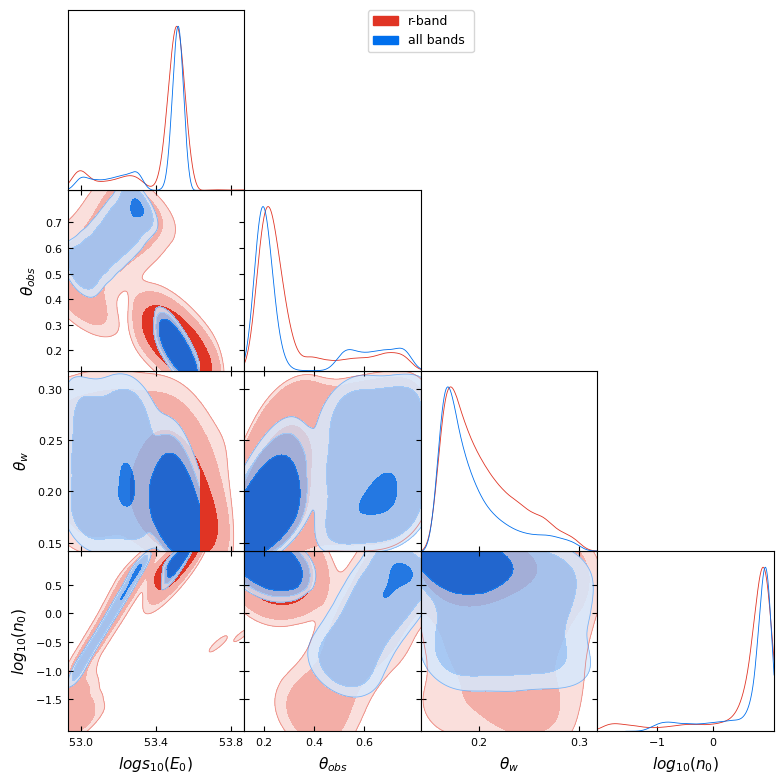

In [105]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.triangle_plot([samples_one_band, samples_all_bands], filled=True, legend_labels=['r-band', 'all bands '])

# Parameters values and shape of the light curve

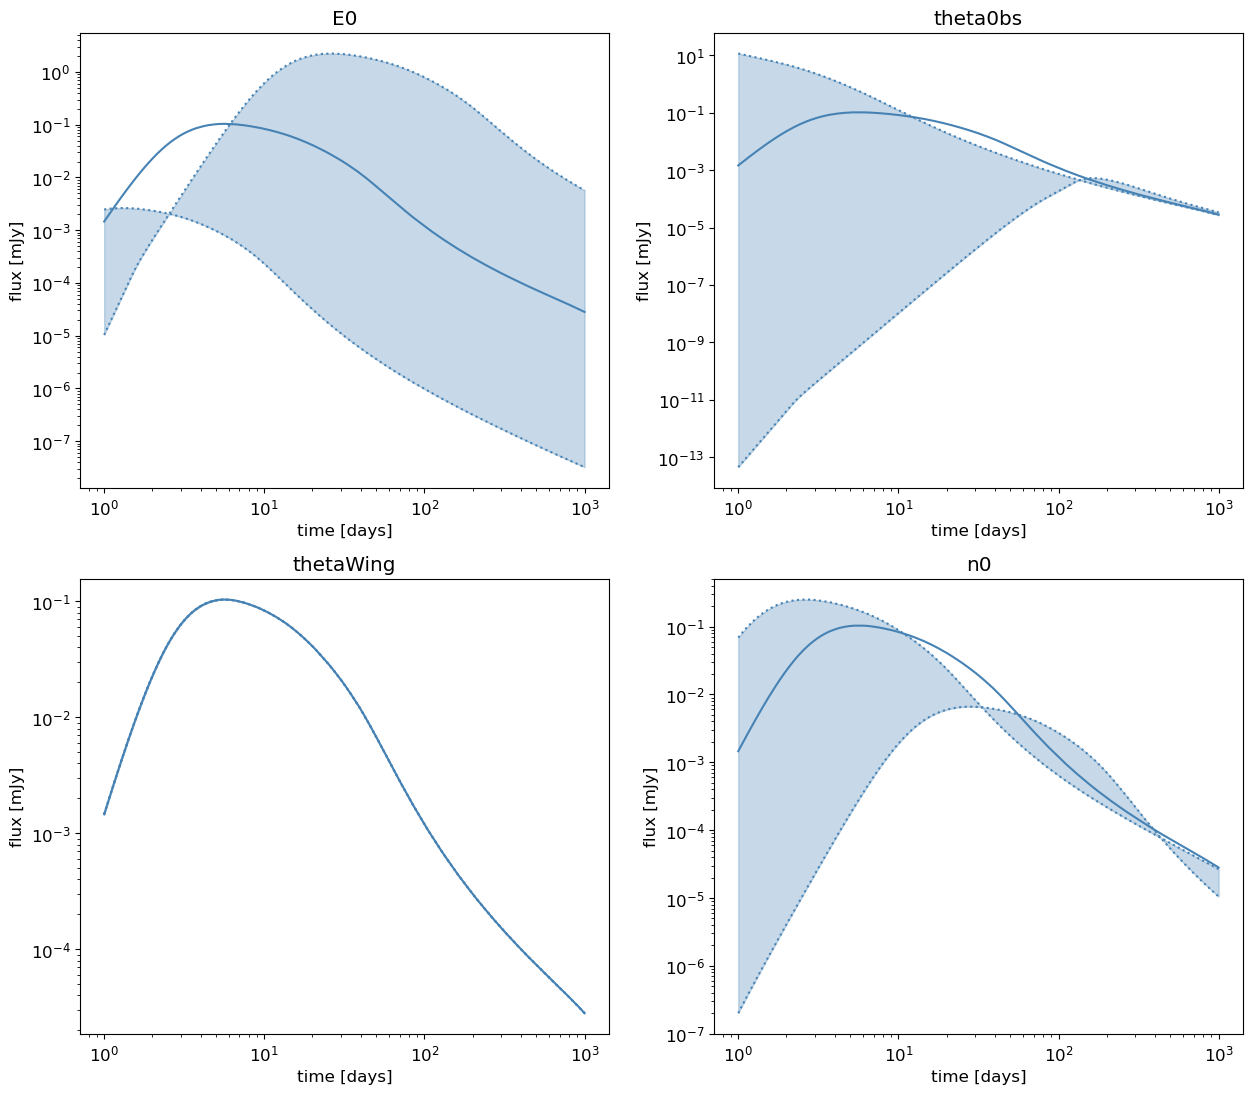

In [111]:
titles = ['E0', 'theta0bs', 'thetaWing', 'n0', 'z']

# [log10(E0), thetaObs, thetaWing, log10(n0), z] paramaters studied over the range of their value
mean_params = (53., 0.3, 0.3, 0.)
max_params = np.array([55., np.pi/4, 0.3, 1.])
min_params = np.array([51., 0.26, 0.16, -2])

time = np.geomspace(1., 1000, 300)
nu = all_nu[2]   # r-band

# "mean" light curve for comparison
mean_model = model(time, nu, mean_params)


fig, axes = plt.subplots(figsize=(15,13), nrows=2, ncols=3)

# for each parameters, the light curves corresponding to its "max" value and its "min" value are calculated 
# and plotted to see if this parameters has a lot of impact in the shape of the light curve
for i in range(len(mean_params)):
    
    ax = plt.subplot(2,2,i+1)

    params = list(mean_params)
    
    params[i] = max_params[i]
    max_model = model(time, nu, params)
    
    params[i] = min_params[i]
    min_model = model(time, nu, params)
    
    plt.plot(time, mean_model, color="#4682b4")
    plt.plot(time, max_model, linestyle=':', color="#4682b4")
    plt.plot(time, min_model, linestyle=':', color="#4682b4")
    plt.fill_between(time, min_model, max_model, color="#4682b4", alpha = 0.3)
    
    plt.title(titles[i])
    plt.xlabel('time [days]')
    plt.ylabel('flux [mJy]')
    plt.xscale('log')
    plt.yscale('log')
    
#axes[1][2].set_visible(False)
#axes[0][0].set_ylabel('flux [mJy]')
#axes[1][0].set_ylabel('flux [mJy]')
plt.show()